# Simulador de sesgos de trading
-Carlos Romo
-Pablo Tafolla 
-Miguel Moran
-Jose Sanchez
## Informe final de los ocho escenarios

Este cuaderno comprueba si dos medidas habituales —efecto disposición y relación entre rotación y desempeño— recuperan sesgos que conocemos de antemano porque fueron introducidos en una población simulada.

> **Resultado principal:** el simulador reconoce correctamente la intensidad del efecto disposición y el aumento de actividad provocado por la sobreconfianza. También demuestra una limitación importante: rebalancear o creer en reversión a la media puede producir una señal de disposición casi idéntica a un sesgo psicológico real.

La lectura está organizada como un informe visual. El código queda oculto por defecto, pero permanece reproducible dentro del notebook.


## Qué se simuló

Se generan **1,000 inversionistas**, **50 activos** y **500 días de mercado**. Cada cuenta comienza con entre **$10,000 y $500,000** y mantiene entre **5 y 30 posiciones**.

- **Disposición (delta):** aumenta la venta de posiciones ganadoras y reduce la venta de perdedoras.
- **Rotación o sobreconfianza (kappa):** aumenta la frecuencia base de compraventa.
- **Costos:** cada operación paga 10 puntos base de comisión y cruza un spread total de 20 puntos base.
- **Separación bruto/neto:** el libro bruto opera al precio medio sin costos; el neto ejecuta al bid/ask y paga comisión.
- **Precios:** se generan antes de cualquier decisión mediante un mercado factorial correlacionado. Ningún trader puede afectar ni conocer retornos futuros.

La simulación liquida **posiciones completas**, no fracciones. Por ello cada venta cuenta como una realización. Se usa el precio medio de compra como costo de referencia; una posición exactamente en el punto de compra es neutral y no entra en PGR ni PLR. Los días sin ventas no aportan ningún conteo.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 123
rng = np.random.default_rng(SEED)

N_TRADERS = 1000
N_ASSETS = 50
N_DAYS = 500

INITIAL_PRICE = 100.0

COMMISSION_BPS = 10
SPREAD_BPS = 20

TRADING_DAYS = 252

MARKET_VOL_ANNUAL = 0.15

mu_annual = rng.uniform(0.05, 0.12, N_ASSETS)
beta_assets = rng.uniform(0.7, 1.3, N_ASSETS)
idio_vol_annual = rng.uniform(0.15, 0.30, N_ASSETS)

total_vol_annual = np.sqrt(
    (beta_assets * MARKET_VOL_ANNUAL) ** 2
    + idio_vol_annual ** 2
)

market_factor = rng.normal(
    loc=0.0,
    scale=MARKET_VOL_ANNUAL / np.sqrt(TRADING_DAYS),
    size=N_DAYS
)

idio_shocks = rng.normal(
    loc=0.0,
    scale=idio_vol_annual / np.sqrt(TRADING_DAYS),
    size=(N_DAYS, N_ASSETS)
)

daily_log_drift = (
    mu_annual - 0.5 * total_vol_annual ** 2
) / TRADING_DAYS

log_returns = (
    daily_log_drift[None, :]
    + market_factor[:, None] * beta_assets[None, :]
    + idio_shocks
)

prices = np.empty((N_DAYS + 1, N_ASSETS))

prices[0, :] = INITIAL_PRICE

prices[1:, :] = INITIAL_PRICE * np.exp(
    np.cumsum(log_returns, axis=0)
)

asset_names = [f"Asset_{j:02d}" for j in range(N_ASSETS)]

prices_df = pd.DataFrame(
    prices,
    columns=asset_names
)

prices_df.index.name = "day"

returns_df = pd.DataFrame(
    log_returns,
    columns=asset_names
)

commission_rate = COMMISSION_BPS / 10_000
spread_rate = SPREAD_BPS / 10_000
half_spread = spread_rate / 2

def ask_price(mid_price):
    return mid_price * (1 + half_spread)


def bid_price(mid_price):
    return mid_price * (1 - half_spread)

BASE_SELL_HAZARD = 0.005
KAPPA_HAZARD_SCALE = 0.005

def portfolio_wealth(holdings_matrix, cash_vector, day):
    """
    Calcula la riqueza total de cada trader en un día determinado,
    valuando todas las posiciones al precio medio de mercado.
    """

    # Valor de mercado de todas las posiciones de cada trader
    invested_value = holdings_matrix @ prices[day, :]

    # Riqueza total = activos invertidos + efectivo
    total_wealth = invested_value + cash_vector

    return total_wealth

def portfolio_beta_exposure(
    holdings_matrix,
    day
):
    """
    Calcula la beta ponderada del portafolio de cada trader.
    """

    # Valor de cada posición
    position_values = (
        holdings_matrix
        * prices[day, :][None, :]
    )

    # Valor total invertido
    invested_value = position_values.sum(
        axis=1
    )

    # Suma ponderada de las betas
    beta_numerator = (
        position_values
        * beta_assets[None, :]
    ).sum(axis=1)

    # Beta del portafolio
    portfolio_beta = np.divide(
        beta_numerator,
        invested_value,
        out=np.zeros_like(
            invested_value
        ),
        where=invested_value > 0
    )

    return portfolio_beta


## El mercado antes de que alguien opere

Los activos comparten un factor de mercado y, a la vez, reciben shocks propios. Esto crea correlación sin hacer que todos se muevan igual. Lo decisivo para la validez del experimento es el orden: primero nace toda la trayectoria de precios y después se toman las decisiones.


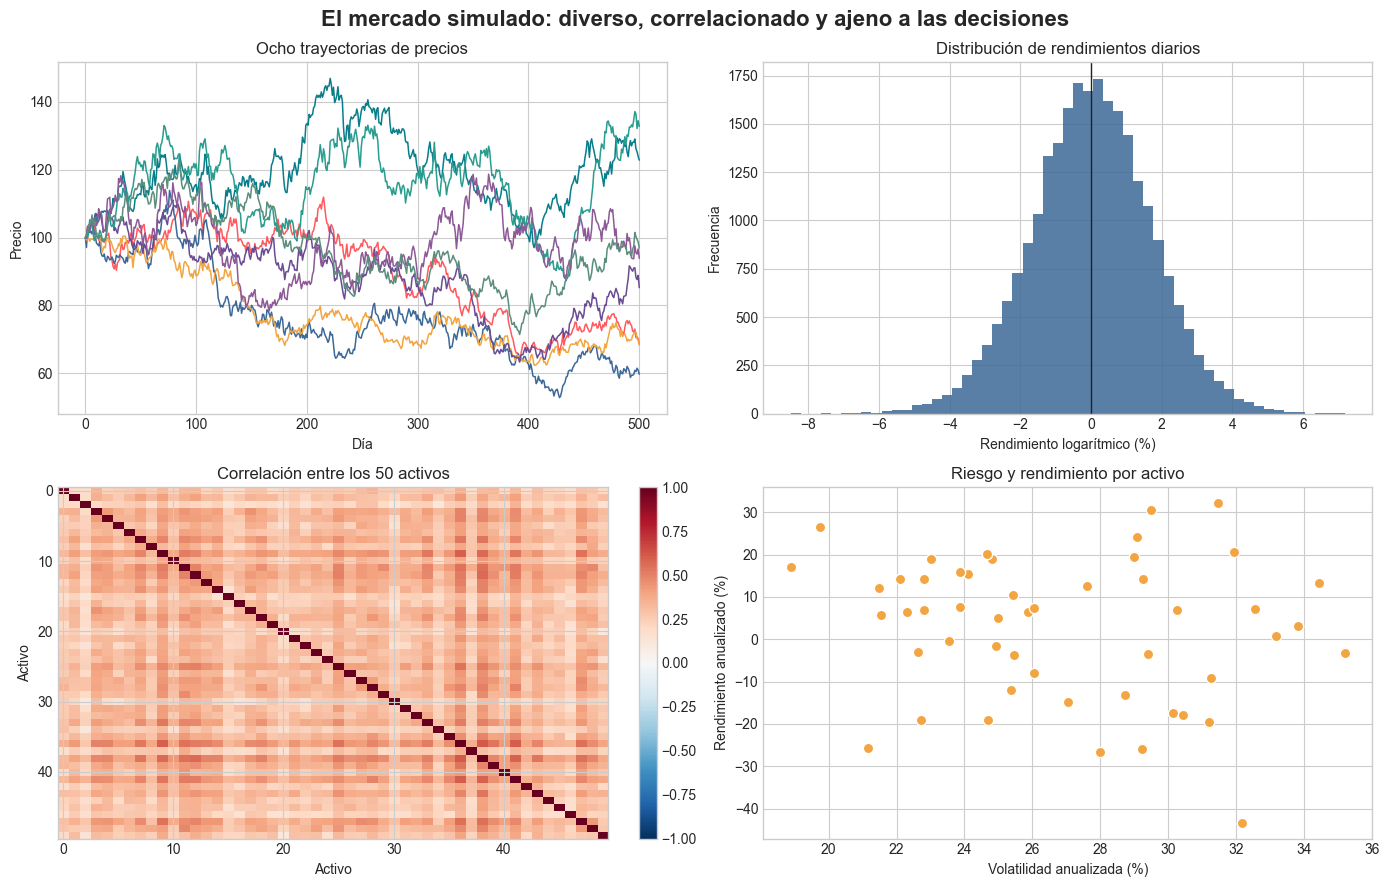

Correlación promedio entre pares de activos: 0.318


In [3]:
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#087E8B", "#FF5A5F", "#3C6997", "#F2A541", "#6A4C93", "#2A9D8F", "#8D5A97", "#5B8E7D"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
prices_df.iloc[:, :8].plot(ax=axes[0, 0], linewidth=1.1, legend=False, color=COLORS)
axes[0, 0].set_title("Ocho trayectorias de precios")
axes[0, 0].set_xlabel("Día")
axes[0, 0].set_ylabel("Precio")

axes[0, 1].hist(log_returns.ravel() * 100, bins=55, color="#3C6997", alpha=0.85)
axes[0, 1].axvline(0, color="#222222", linewidth=1)
axes[0, 1].set_title("Distribución de rendimientos diarios")
axes[0, 1].set_xlabel("Rendimiento logarítmico (%)")
axes[0, 1].set_ylabel("Frecuencia")

corr = returns_df.corr()
im = axes[1, 0].imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
axes[1, 0].set_title("Correlación entre los 50 activos")
axes[1, 0].set_xlabel("Activo")
axes[1, 0].set_ylabel("Activo")
fig.colorbar(im, ax=axes[1, 0], fraction=0.046)

asset_mean = returns_df.mean() * 252 * 100
asset_vol = returns_df.std() * np.sqrt(252) * 100
axes[1, 1].scatter(asset_vol, asset_mean, color="#F2A541", edgecolor="white", s=55)
axes[1, 1].set_title("Riesgo y rendimiento por activo")
axes[1, 1].set_xlabel("Volatilidad anualizada (%)")
axes[1, 1].set_ylabel("Rendimiento anualizado (%)")

fig.suptitle("El mercado simulado: diverso, correlacionado y ajeno a las decisiones", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()
print(f"Correlación promedio entre pares de activos: {corr.values[~np.eye(N_ASSETS, dtype=bool)].mean():.3f}")


## Cómo se toman las decisiones

PGR y PLR no son parámetros introducidos directamente. La probabilidad diaria de vender parte de un hazard base. Delta lo multiplica hacia arriba si la posición está ganando y hacia abajo si está perdiendo; kappa eleva el hazard base para todos los dominios. De ese proceso emergen PGR, PLR y turnover.

Cada venta se reinvierte el mismo día en un activo distinto. Así se elimina el arrastre de efectivo como explicación artificial de una pendiente bruta. Las compras y ventas gross y net siguen exactamente las mismas decisiones; sólo difieren en costos.


In [4]:
BIAS_CONCENTRATION = 20


def generate_bias_parameter(
    target_mean,
    n_traders,
    rng
):
    """
    Genera intensidades individuales entre 0 y 1
    cuya media poblacional esperada es target_mean.

    Si target_mean = 0, todos los traders reciben 0.
    """

    if target_mean == 0:
        return np.zeros(n_traders)

    alpha = (
        target_mean
        * BIAS_CONCENTRATION
    )

    beta_param = (
        (1 - target_mean)
        * BIAS_CONCENTRATION
    )

    values = rng.beta(
        alpha,
        beta_param,
        size=n_traders
    )

    return values

def generate_scenario_biases(
    delta_target,
    kappa_target,
    seed
):
    """
    Genera delta_i y kappa_i de forma independiente.

    delta_target y kappa_target representan
    las intensidades promedio especificadas
    para cada escenario.
    """

    rng_delta = np.random.default_rng(
        seed
    )

    rng_kappa = np.random.default_rng(
        seed + 1
    )

    delta_vec = generate_bias_parameter(
        target_mean=delta_target,
        n_traders=N_TRADERS,
        rng=rng_delta
    )

    kappa_vec = generate_bias_parameter(
        target_mean=kappa_target,
        n_traders=N_TRADERS,
        rng=rng_kappa
    )

    return delta_vec, kappa_vec

def generate_population(
    delta_target,
    kappa_target,
    seed
):
    """
    Genera una población nueva de traders para un escenario.

    Cada trader recibe:
    - delta_i
    - kappa_i
    - capital inicial
    - número de posiciones

    delta_i y kappa_i se generan independientemente.
    """

    # --------------------------------------------------
    # 1. Sesgos conductuales
    # --------------------------------------------------

    delta_vec, kappa_vec = generate_scenario_biases(
        delta_target=delta_target,
        kappa_target=kappa_target,
        seed=seed
    )

    # --------------------------------------------------
    # 2. Generador separado para riqueza
    # --------------------------------------------------

    rng_wealth = np.random.default_rng(
        seed + 100
    )

    starting_wealth_vec = rng_wealth.uniform(
        10_000,
        500_000,
        N_TRADERS
    )

    # --------------------------------------------------
    # 3. Generador separado para número de posiciones
    # --------------------------------------------------

    rng_positions = np.random.default_rng(
        seed + 200
    )

    n_positions_vec = rng_positions.integers(
        5,
        31,
        N_TRADERS
    )

    # --------------------------------------------------
    # 4. Tabla de población
    # --------------------------------------------------

    population_df = pd.DataFrame({
        "trader_id": np.arange(N_TRADERS),
        "delta": delta_vec,
        "kappa": kappa_vec,
        "starting_wealth": starting_wealth_vec,
        "n_positions": n_positions_vec
    })

    return population_df

def build_initial_portfolios(
    population_df,
    seed
):
    """
    Construye los portafolios iniciales bruto y neto
    para una población determinada.
    """

    n_traders = len(population_df)

    # --------------------------------------------------
    # 1. Crear matrices vacías
    # --------------------------------------------------

    holdings_gross_new = np.zeros(
        (n_traders, N_ASSETS)
    )

    holdings_net_new = np.zeros(
        (n_traders, N_ASSETS)
    )

    cost_basis_new = np.full(
        (n_traders, N_ASSETS),
        np.nan
    )

    # --------------------------------------------------
    # 2. Capital inicial
    # --------------------------------------------------

    wealth_vec = population_df[
        "starting_wealth"
    ].to_numpy()

    n_positions_vec = population_df[
        "n_positions"
    ].to_numpy()

    cash_gross_new = wealth_vec.copy()
    cash_net_new = wealth_vec.copy()

    # Generador exclusivo para composición del portafolio
    rng_portfolio = np.random.default_rng(
        seed
    )

    # --------------------------------------------------
    # 3. Construir portafolio de cada trader
    # --------------------------------------------------

    for i in range(n_traders):

        # Elegir activos distintos
        chosen_assets = rng_portfolio.choice(
            N_ASSETS,
            size=n_positions_vec[i],
            replace=False
        )

        # Portafolio equiponderado
        budget_per_asset = (
            wealth_vec[i]
            / n_positions_vec[i]
        )

        for j in chosen_assets:

            mid = prices[0, j]

            # ==========================================
            # PORTAFOLIO BRUTO
            # ==========================================

            gross_shares = (
                budget_per_asset
                / mid
            )

            holdings_gross_new[
                i, j
            ] = gross_shares

            cash_gross_new[i] -= (
                gross_shares * mid
            )

            # ==========================================
            # PORTAFOLIO NETO
            # ==========================================

            buy_price = ask_price(mid)

            net_shares = (
                budget_per_asset
                /
                (
                    buy_price
                    * (1 + commission_rate)
                )
            )

            transaction_value = (
                net_shares
                * buy_price
            )

            commission = (
                transaction_value
                * commission_rate
            )

            holdings_net_new[
                i, j
            ] = net_shares

            cash_net_new[i] -= (
                transaction_value
                + commission
            )

            # Punto de referencia conductual
            cost_basis_new[i, j] = mid

    return {
        "holdings_gross": holdings_gross_new,
        "holdings_net": holdings_net_new,
        "cost_basis": cost_basis_new,
        "cash_gross": cash_gross_new,
        "cash_net": cash_net_new
    }

def simulate_full_period_v2(
    holdings_gross_initial,
    holdings_net_initial,
    cost_basis_initial,
    cash_gross_initial,
    cash_net_initial,
    starting_wealth_vec,
    n_positions_vec,
    delta_vec,
    kappa_vec,
    seed,
    n_days=N_DAYS,
    show_progress=True
):
    """
    Simula un escenario completo durante n_days.

    Registra para cada trader:
    - riqueza bruta
    - riqueza neta
    - turnover
    - costos de transacción
    - número de ventas
    - exposición beta promedio

    También registra:
    - todas las operaciones
    - G_r, G_p, L_r y L_p
    """

    # ==================================================
    # 1. TAMAÑO DE LA POBLACIÓN
    # ==================================================

    n_traders = len(delta_vec)

    # ==================================================
    # 2. COPIAR EL ESTADO INICIAL
    # ==================================================

    holdings_gross = holdings_gross_initial.copy()
    holdings_net = holdings_net_initial.copy()

    cost_basis = cost_basis_initial.copy()

    cash_gross = cash_gross_initial.copy()
    cash_net = cash_net_initial.copy()

    # Generador aleatorio exclusivo para este escenario
    sim_rng = np.random.default_rng(seed)

    # ==================================================
    # 3. ESTRUCTURAS PARA GUARDAR RESULTADOS
    # ==================================================

    gross_wealth_history = np.zeros(
        (n_days + 1, n_traders)
    )

    net_wealth_history = np.zeros(
        (n_days + 1, n_traders)
    )

    cumulative_turnover = np.zeros(
        n_traders
    )

    cumulative_costs = np.zeros(
        n_traders
    )

    beta_sum = np.zeros(
        n_traders
    )

    beta_count = np.zeros(
        n_traders
    )

    sell_count = np.zeros(
        n_traders,
        dtype=int
    )

    trade_records = []

    disposition_records = []

    # ==================================================
    # 4. RIQUEZA INICIAL
    # ==================================================

    gross_wealth_history[0] = portfolio_wealth(
        holdings_gross,
        cash_gross,
        day=0
    )

    net_wealth_history[0] = portfolio_wealth(
        holdings_net,
        cash_net,
        day=0
    )

    # ==================================================
    # 5. COSTOS DEL PORTAFOLIO INICIAL
    # ==================================================

    initial_costs = (
        starting_wealth_vec
        - net_wealth_history[0]
    )

    cumulative_costs += initial_costs

    # ==================================================
    # 6. RECORRER TODOS LOS DÍAS
    # ==================================================

    for day in range(1, n_days + 1):

        if show_progress and (
            day == 1
            or day % 50 == 0
            or day == n_days
        ):
            print(
                f"Simulando día {day} de {n_days}..."
            )

        # --------------------------------------------------
        # Riqueza antes de operar
        # --------------------------------------------------

        gross_wealth_pretrade = portfolio_wealth(
            holdings_gross,
            cash_gross,
            day
        )

        # ==================================================
        # 7. RECORRER TRADERS
        # ==================================================

        for i in range(n_traders):

            # Activos mantenidos al inicio del día
            held_assets = np.where(
                holdings_net[i] > 0
            )[0]

            if len(held_assets) == 0:
                continue

            # Precios actuales
            current_prices = prices[
                day,
                held_assets
            ]

            # Costos base
            references = cost_basis[
                i,
                held_assets
            ]

            # ==================================================
            # 8. CLASIFICAR POSICIONES
            # ==================================================

            neutral_mask = np.isclose(
                current_prices,
                references,
                rtol=0.0,
                atol=1e-10
            )

            gain_mask = (
                current_prices > references
            ) & (~neutral_mask)

            loss_mask = (
                current_prices < references
            ) & (~neutral_mask)

            # 1 = ganancia
            # -1 = pérdida
            # 0 = neutral
            domains = np.zeros(
                len(held_assets),
                dtype=int
            )

            domains[gain_mask] = 1
            domains[loss_mask] = -1

            # ==================================================
            # 9. HAZARD BASE
            # ==================================================

            base_hazard = (
                BASE_SELL_HAZARD
                +
                KAPPA_HAZARD_SCALE
                * kappa_vec[i]
            )

            sell_probs = np.full(
                len(held_assets),
                base_hazard
            )

            # ==================================================
            # 10. EFECTO DISPOSICIÓN
            # ==================================================

            sell_probs[gain_mask] *= (
                1 + delta_vec[i]
            )

            sell_probs[loss_mask] *= (
                1 - delta_vec[i]
            )

            sell_probs = np.clip(
                sell_probs,
                0.0,
                1.0
            )

            # ==================================================
            # 11. DECISIÓN DE VENTA
            # ==================================================

            random_draws = sim_rng.random(
                len(held_assets)
            )

            sell_mask = (
                random_draws < sell_probs
            )

            # Si no vende nada, no cuenta para PGR/PLR
            if not np.any(sell_mask):
                continue

            sold_assets = held_assets[
                sell_mask
            ]

            # IMPORTANTE:
            # activos vendidos durante este día
            sold_set = set(
                sold_assets.tolist()
            )

            sold_domains = domains[
                sell_mask
            ]

            paper_domains = domains[
                ~sell_mask
            ]

            # ==================================================
            # 12. CONTEOS DE ODEAN
            # ==================================================

            G_r = np.sum(
                sold_domains == 1
            )

            L_r = np.sum(
                sold_domains == -1
            )

            G_p = np.sum(
                paper_domains == 1
            )

            L_p = np.sum(
                paper_domains == -1
            )

            disposition_records.append({
                "day": day,
                "trader_id": i,
                "G_r": int(G_r),
                "G_p": int(G_p),
                "L_r": int(L_r),
                "L_p": int(L_p)
            })

            # ==================================================
            # 13. EJECUTAR CADA VENTA
            # ==================================================

            for local_idx, j in enumerate(
                sold_assets
            ):

                mid_price = prices[
                    day,
                    j
                ]

                domain_code = sold_domains[
                    local_idx
                ]

                if domain_code == 1:
                    domain_text = "gain"

                elif domain_code == -1:
                    domain_text = "loss"

                else:
                    domain_text = "neutral"

                # ==============================================
                # PORTAFOLIO BRUTO: VENTA
                # ==============================================

                gross_shares = (
                    holdings_gross[
                        i,
                        j
                    ]
                )

                gross_proceeds = (
                    gross_shares
                    * mid_price
                )

                cash_gross[i] += (
                    gross_proceeds
                )

                # ==============================================
                # PORTAFOLIO NETO: VENTA
                # ==============================================

                net_shares = (
                    holdings_net[
                        i,
                        j
                    ]
                )

                sell_execution_price = (
                    bid_price(
                        mid_price
                    )
                )

                sell_value = (
                    net_shares
                    * sell_execution_price
                )

                sell_commission = (
                    sell_value
                    * commission_rate
                )

                net_proceeds = (
                    sell_value
                    - sell_commission
                )

                cash_net[i] += (
                    net_proceeds
                )

                # ==============================================
                # COSTO DEL SPREAD DE VENTA
                # ==============================================

                sell_spread_cost = (
                    abs(
                        sell_execution_price
                        - mid_price
                    )
                    * net_shares
                )

                cumulative_costs[i] += (
                    sell_commission
                    + sell_spread_cost
                )

                # ==============================================
                # TURNOVER
                # ==============================================

                if gross_wealth_pretrade[i] > 0:

                    cumulative_turnover[i] += (
                        gross_proceeds
                        / gross_wealth_pretrade[i]
                    )

                sell_count[i] += 1

                # ==============================================
                # REGISTRAR VENTA
                # ==============================================

                trade_records.append({
                    "day": day,
                    "trader_id": i,
                    "asset": asset_names[j],
                    "side": "SELL",
                    "domain": domain_text,
                    "mid_price": mid_price,
                    "execution_price":
                        sell_execution_price,
                    "shares": net_shares,
                    "commission":
                        sell_commission,
                    "spread_cost":
                        sell_spread_cost
                })

                # ==============================================
                # ELIMINAR POSICIÓN
                # ==============================================

                holdings_gross[
                    i,
                    j
                ] = 0.0

                holdings_net[
                    i,
                    j
                ] = 0.0

                cost_basis[
                    i,
                    j
                ] = np.nan

                # ==================================================
                # 14. ELEGIR ACTIVO DE REEMPLAZO
                # ==================================================

                currently_held = set(
                    np.where(
                        holdings_net[i] > 0
                    )[0].tolist()
                )

                # No se puede:
                # - comprar algo ya mantenido
                # - recomprar ningún activo vendido ese día
                eligible_assets = [
                    x
                    for x in range(N_ASSETS)
                    if x not in currently_held
                    and x not in sold_set
                ]

                new_j = sim_rng.choice(
                    eligible_assets
                )

                new_mid = prices[
                    day,
                    new_j
                ]

                # ==============================================
                # PORTAFOLIO BRUTO: COMPRA
                # ==============================================

                gross_new_shares = (
                    gross_proceeds
                    / new_mid
                )

                holdings_gross[
                    i,
                    new_j
                ] = gross_new_shares

                cash_gross[i] -= (
                    gross_proceeds
                )

                # ==============================================
                # PORTAFOLIO NETO: COMPRA
                # ==============================================

                buy_execution_price = (
                    ask_price(
                        new_mid
                    )
                )

                net_new_shares = (
                    net_proceeds
                    /
                    (
                        buy_execution_price
                        * (1 + commission_rate)
                    )
                )

                buy_value = (
                    net_new_shares
                    * buy_execution_price
                )

                buy_commission = (
                    buy_value
                    * commission_rate
                )

                buy_spread_cost = (
                    abs(
                        buy_execution_price
                        - new_mid
                    )
                    * net_new_shares
                )

                holdings_net[
                    i,
                    new_j
                ] = net_new_shares

                cash_net[i] -= (
                    buy_value
                    + buy_commission
                )

                # Nuevo punto de referencia
                cost_basis[
                    i,
                    new_j
                ] = new_mid

                # Costos de compra
                cumulative_costs[i] += (
                    buy_commission
                    + buy_spread_cost
                )

                # ==============================================
                # REGISTRAR COMPRA
                # ==============================================

                trade_records.append({
                    "day": day,
                    "trader_id": i,
                    "asset": asset_names[new_j],
                    "side": "BUY",
                    "domain": "replacement",
                    "mid_price": new_mid,
                    "execution_price":
                        buy_execution_price,
                    "shares":
                        net_new_shares,
                    "commission":
                        buy_commission,
                    "spread_cost":
                        buy_spread_cost
                })

        # ==================================================
        # 15. BETA DEL PORTAFOLIO
        # ==================================================

        beta_today = (
            portfolio_beta_exposure(
                holdings_net,
                day
            )
        )

        beta_sum += beta_today
        beta_count += 1

        # ==================================================
        # 16. RIQUEZA AL FINAL DEL DÍA
        # ==================================================

        gross_wealth_history[
            day
        ] = portfolio_wealth(
            holdings_gross,
            cash_gross,
            day
        )

        net_wealth_history[
            day
        ] = portfolio_wealth(
            holdings_net,
            cash_net,
            day
        )

    # ==================================================
    # 17. CONVERTIR REGISTROS A DATAFRAME
    # ==================================================

    trades_all = pd.DataFrame(
        trade_records
    )

    disposition_all = pd.DataFrame(
        disposition_records
    )

    # ==================================================
    # 18. BETA PROMEDIO
    # ==================================================

    avg_beta = np.divide(
        beta_sum,
        beta_count,
        out=np.zeros_like(
            beta_sum
        ),
        where=beta_count > 0
    )

    # ==================================================
    # 19. RENDIMIENTOS TOTALES
    # ==================================================

    gross_total_return = (
        gross_wealth_history[-1]
        / starting_wealth_vec
        - 1
    )

    net_total_return = (
        net_wealth_history[-1]
        / starting_wealth_vec
        - 1
    )

    # ==================================================
    # 20. RENDIMIENTOS ANUALIZADOS
    # ==================================================

    gross_ann_return = (
        (
            gross_wealth_history[-1]
            / starting_wealth_vec
        )
        ** (
            TRADING_DAYS / n_days
        )
        - 1
    )

    net_ann_return = (
        (
            net_wealth_history[-1]
            / starting_wealth_vec
        )
        ** (
            TRADING_DAYS / n_days
        )
        - 1
    )

    # ==================================================
    # 21. TURNOVER ANUALIZADO
    # ==================================================

    annualized_turnover = (
        cumulative_turnover
        * TRADING_DAYS
        / n_days
    )

    # ==================================================
    # 22. TABLA FINAL POR TRADER
    # ==================================================

    trader_summary = pd.DataFrame({
        "trader_id":
            np.arange(n_traders),

        "delta":
            delta_vec,

        "kappa":
            kappa_vec,

        "starting_wealth":
            starting_wealth_vec,

        "n_positions":
            n_positions_vec,

        "gross_final_wealth":
            gross_wealth_history[-1],

        "net_final_wealth":
            net_wealth_history[-1],

        "gross_total_return":
            gross_total_return,

        "net_total_return":
            net_total_return,

        "gross_ann_return":
            gross_ann_return,

        "net_ann_return":
            net_ann_return,

        "turnover_total":
            cumulative_turnover,

        "turnover_annualized":
            annualized_turnover,

        "total_costs":
            cumulative_costs,

        "sell_count":
            sell_count,

        "avg_beta":
            avg_beta
    })

    # ==================================================
    # 23. DEVOLVER RESULTADOS
    # ==================================================

    return {
        "summary":
            trader_summary,

        "trades":
            trades_all,

        "disposition":
            disposition_all,

        "gross_wealth_history":
            gross_wealth_history,

        "net_wealth_history":
            net_wealth_history,

        "final_holdings_gross":
            holdings_gross,

        "final_holdings_net":
            holdings_net,

        "final_cost_basis":
            cost_basis,

        "final_cash_gross":
            cash_gross,

        "final_cash_net":
            cash_net
    }

def run_scenario(
    scenario_id,
    delta_target,
    kappa_target,
    seed,
    show_progress=True
):
    """
    Genera una nueva población, construye sus portafolios
    y ejecuta un escenario completo de 500 días.
    """

    # 1. Nueva población
    population = generate_population(
        delta_target=delta_target,
        kappa_target=kappa_target,
        seed=seed
    )

    # 2. Nuevos portafolios
    portfolios = build_initial_portfolios(
        population_df=population,
        seed=seed + 100
    )

    # 3. Extraer variables individuales
    delta_vec = population["delta"].to_numpy()
    kappa_vec = population["kappa"].to_numpy()
    wealth_vec = population["starting_wealth"].to_numpy()
    positions_vec = population["n_positions"].to_numpy()

    # 4. Ejecutar simulación
    results = simulate_full_period_v2(
        holdings_gross_initial=
            portfolios["holdings_gross"],

        holdings_net_initial=
            portfolios["holdings_net"],

        cost_basis_initial=
            portfolios["cost_basis"],

        cash_gross_initial=
            portfolios["cash_gross"],

        cash_net_initial=
            portfolios["cash_net"],

        starting_wealth_vec=
            wealth_vec,

        n_positions_vec=
            positions_vec,

        delta_vec=
            delta_vec,

        kappa_vec=
            kappa_vec,

        seed=seed + 200,

        n_days=N_DAYS,

        show_progress=show_progress
    )

    # 5. Guardar información del escenario
    results["population"] = population
    results["scenario_id"] = scenario_id
    results["delta_target"] = delta_target
    results["kappa_target"] = kappa_target

    return results

REBALANCE_THRESHOLD = 1.15
REBALANCE_EXTRA_HAZARD = 0.025

MR_LOOKBACK = 20
MR_THRESHOLD = 0.03
MR_EXTRA_HAZARD = 0.025


def simulate_confound_period(
    population,
    portfolios,
    confound,
    seed,
    show_progress=True
):
    """
    Simula los escenarios confusores:

    confound = "rebalancing"
    confound = "mean_reversion"

    En ambos casos:
    delta = 0
    kappa = 0
    """

    rng_sim = np.random.default_rng(seed)

    hg = portfolios["holdings_gross"].copy()
    hn = portfolios["holdings_net"].copy()
    cb = portfolios["cost_basis"].copy()

    cg = portfolios["cash_gross"].copy()
    cn = portfolios["cash_net"].copy()

    wealth = population[
        "starting_wealth"
    ].to_numpy()

    n_positions_vec = population[
        "n_positions"
    ].to_numpy()

    n_traders = len(population)

    turnover = np.zeros(n_traders)
    total_costs = np.zeros(n_traders)
    sell_count = np.zeros(
        n_traders,
        dtype=int
    )

    beta_sum = np.zeros(n_traders)

    trades = []
    disposition = []

    # -----------------------------------------
    # Costos iniciales
    # -----------------------------------------

    initial_net_wealth = portfolio_wealth(
        hn,
        cn,
        day=0
    )

    total_costs += (
        wealth
        - initial_net_wealth
    )

    # =========================================
    # SIMULACIÓN
    # =========================================

    for day in range(1, N_DAYS + 1):

        if show_progress and (
            day == 1
            or day % 50 == 0
            or day == N_DAYS
        ):
            print(
                f"Simulando día {day} "
                f"de {N_DAYS}..."
            )

        gross_pretrade = portfolio_wealth(
            hg,
            cg,
            day
        )

        for i in range(n_traders):

            held = np.where(
                hn[i] > 0
            )[0]

            if len(held) == 0:
                continue

            current = prices[
                day,
                held
            ]

            reference = cb[
                i,
                held
            ]

            neutral = np.isclose(
                current,
                reference,
                rtol=0.0,
                atol=1e-10
            )

            gains = (
                current > reference
            ) & (~neutral)

            losses = (
                current < reference
            ) & (~neutral)

            domains = np.zeros(
                len(held),
                dtype=int
            )

            domains[gains] = 1
            domains[losses] = -1

            # ---------------------------------
            # Probabilidad normal de venta
            # ---------------------------------

            sell_probs = np.full(
                len(held),
                BASE_SELL_HAZARD
            )

            # =================================
            # CONFUSOR 7: REBALANCING
            # =================================

            if confound == "rebalancing":

                values = (
                    hn[i, held]
                    * current
                )

                weights = (
                    values
                    / values.sum()
                )

                target_weight = (
                    1 / len(held)
                )

                overweight = (
                    weights
                    >
                    REBALANCE_THRESHOLD
                    * target_weight
                )

                sell_probs[
                    overweight
                ] += REBALANCE_EXTRA_HAZARD

            # =================================
            # CONFUSOR 8: MEAN REVERSION
            # =================================

            elif confound == "mean_reversion":

                if day >= MR_LOOKBACK:

                    recent_return = (
                        prices[
                            day,
                            held
                        ]
                        /
                        prices[
                            day - MR_LOOKBACK,
                            held
                        ]
                        - 1
                    )

                    recent_winners = (
                        recent_return
                        > MR_THRESHOLD
                    )

                    sell_probs[
                        recent_winners
                    ] += MR_EXTRA_HAZARD

            sell_probs = np.clip(
                sell_probs,
                0,
                1
            )

            sell_mask = (
                rng_sim.random(
                    len(held)
                )
                < sell_probs
            )

            if not sell_mask.any():
                continue

            sold_assets = held[
                sell_mask
            ]

            sold_set = set(
                sold_assets.tolist()
            )

            sold_domains = domains[
                sell_mask
            ]

            paper_domains = domains[
                ~sell_mask
            ]

            disposition.append({
                "day": day,
                "trader_id": i,
                "G_r": int(
                    np.sum(
                        sold_domains == 1
                    )
                ),
                "G_p": int(
                    np.sum(
                        paper_domains == 1
                    )
                ),
                "L_r": int(
                    np.sum(
                        sold_domains == -1
                    )
                ),
                "L_p": int(
                    np.sum(
                        paper_domains == -1
                    )
                )
            })

            # =================================
            # EJECUTAR VENTAS Y REEMPLAZOS
            # =================================

            for j in sold_assets:

                mid = prices[
                    day,
                    j
                ]

                # -----------------------------
                # Gross sale
                # -----------------------------

                gross_proceeds = (
                    hg[i, j]
                    * mid
                )

                cg[i] += gross_proceeds

                # -----------------------------
                # Net sale
                # -----------------------------

                net_shares = hn[
                    i,
                    j
                ]

                sell_price = bid_price(
                    mid
                )

                sell_value = (
                    net_shares
                    * sell_price
                )

                sell_commission = (
                    sell_value
                    * commission_rate
                )

                net_proceeds = (
                    sell_value
                    - sell_commission
                )

                cn[i] += net_proceeds

                sell_spread = (
                    abs(
                        sell_price
                        - mid
                    )
                    * net_shares
                )

                total_costs[i] += (
                    sell_commission
                    + sell_spread
                )

                if gross_pretrade[i] > 0:

                    turnover[i] += (
                        gross_proceeds
                        /
                        gross_pretrade[i]
                    )

                sell_count[i] += 1

                trades.append({
                    "day": day,
                    "trader_id": i,
                    "side": "SELL"
                })

                hg[i, j] = 0.0
                hn[i, j] = 0.0
                cb[i, j] = np.nan

                # -----------------------------
                # Activos disponibles
                # -----------------------------

                currently_held = set(
                    np.where(
                        hn[i] > 0
                    )[0].tolist()
                )

                eligible = [
                    x
                    for x in range(N_ASSETS)
                    if x not in currently_held
                    and x not in sold_set
                ]

                # -----------------------------
                # Selección del reemplazo
                # -----------------------------

                if (
                    confound == "mean_reversion"
                    and day >= MR_LOOKBACK
                ):

                    eligible_returns = (
                        prices[
                            day,
                            eligible
                        ]
                        /
                        prices[
                            day - MR_LOOKBACK,
                            eligible
                        ]
                        - 1
                    )

                    new_j = eligible[
                        np.argmin(
                            eligible_returns
                        )
                    ]

                else:

                    new_j = rng_sim.choice(
                        eligible
                    )

                new_mid = prices[
                    day,
                    new_j
                ]

                # -----------------------------
                # Gross buy
                # -----------------------------

                hg[
                    i,
                    new_j
                ] = (
                    gross_proceeds
                    / new_mid
                )

                cg[i] -= gross_proceeds

                # -----------------------------
                # Net buy
                # -----------------------------

                buy_price = ask_price(
                    new_mid
                )

                new_shares = (
                    net_proceeds
                    /
                    (
                        buy_price
                        * (
                            1
                            + commission_rate
                        )
                    )
                )

                buy_value = (
                    new_shares
                    * buy_price
                )

                buy_commission = (
                    buy_value
                    * commission_rate
                )

                buy_spread = (
                    abs(
                        buy_price
                        - new_mid
                    )
                    * new_shares
                )

                hn[
                    i,
                    new_j
                ] = new_shares

                cn[i] -= (
                    buy_value
                    + buy_commission
                )

                cb[
                    i,
                    new_j
                ] = new_mid

                total_costs[i] += (
                    buy_commission
                    + buy_spread
                )

                trades.append({
                    "day": day,
                    "trader_id": i,
                    "side": "BUY"
                })

        beta_sum += portfolio_beta_exposure(
            hn,
            day
        )

    # =========================================
    # RESULTADOS FINALES
    # =========================================

    gross_final = portfolio_wealth(
        hg,
        cg,
        N_DAYS
    )

    net_final = portfolio_wealth(
        hn,
        cn,
        N_DAYS
    )

    gross_total_return = (
        gross_final
        / wealth
        - 1
    )

    net_total_return = (
        net_final
        / wealth
        - 1
    )

    gross_ann_return = (
        (
            gross_final
            / wealth
        )
        ** (
            TRADING_DAYS
            / N_DAYS
        )
        - 1
    )

    net_ann_return = (
        (
            net_final
            / wealth
        )
        ** (
            TRADING_DAYS
            / N_DAYS
        )
        - 1
    )

    summary = pd.DataFrame({
        "trader_id":
            np.arange(n_traders),

        "delta":
            np.zeros(n_traders),

        "kappa":
            np.zeros(n_traders),

        "starting_wealth":
            wealth,

        "n_positions":
            n_positions_vec,

        "gross_final_wealth":
            gross_final,

        "net_final_wealth":
            net_final,

        "gross_total_return":
            gross_total_return,

        "net_total_return":
            net_total_return,

        "gross_ann_return":
            gross_ann_return,

        "net_ann_return":
            net_ann_return,

        "turnover_total":
            turnover,

        "turnover_annualized":
            turnover
            * TRADING_DAYS
            / N_DAYS,

        "total_costs":
            total_costs,

        "sell_count":
            sell_count,

        "avg_beta":
            beta_sum
            / N_DAYS
    })

    return {
        "summary": summary,
        "trades": pd.DataFrame(trades),
        "disposition": pd.DataFrame(
            disposition
        )
    }

def run_confound_scenario(
    scenario_id,
    confound,
    seed,
    show_progress=True
):
    """
    Genera una población con delta = kappa = 0
    y ejecuta uno de los escenarios confusores.
    """

    population = generate_population(
        delta_target=0.0,
        kappa_target=0.0,
        seed=seed
    )

    portfolios = build_initial_portfolios(
        population_df=population,
        seed=seed + 100
    )

    results = simulate_confound_period(
        population=population,
        portfolios=portfolios,
        confound=confound,
        seed=seed + 200,
        show_progress=show_progress
    )

    results["population"] = population
    results["scenario_id"] = scenario_id

    return results


In [5]:
def summarize_scenario(
    results,
    scenario_name,
    delta_target,
    kappa_target
):
    """
    Resume los principales resultados de un escenario
    en una sola fila.
    """

    summary = results["summary"]
    trades = results["trades"]
    disposition = results["disposition"]

    # -----------------------------
    # Conteos de disposición
    # -----------------------------

    G_r = disposition["G_r"].sum()
    G_p = disposition["G_p"].sum()
    L_r = disposition["L_r"].sum()
    L_p = disposition["L_p"].sum()

    # -----------------------------
    # PGR y PLR
    # -----------------------------

    PGR = G_r / (G_r + G_p)
    PLR = L_r / (L_r + L_p)

    disposition_effect = PGR - PLR
    disposition_ratio = PGR / PLR

    # -----------------------------
    # Operaciones
    # -----------------------------

    sales = (
        trades["side"] == "SELL"
    ).sum()

    buys = (
        trades["side"] == "BUY"
    ).sum()

    # -----------------------------
    # Correlación delta-kappa
    # -----------------------------

    if (
        summary["delta"].std() > 0
        and summary["kappa"].std() > 0
    ):
        corr_delta_kappa = (
            summary[
                ["delta", "kappa"]
            ]
            .corr()
            .iloc[0, 1]
        )
    else:
        corr_delta_kappa = np.nan

    # -----------------------------
    # Resultado del escenario
    # -----------------------------

    row = {
        "scenario": scenario_name,

        "delta_target":
            delta_target,

        "kappa_target":
            kappa_target,

        "delta_mean":
            summary["delta"].mean(),

        "kappa_mean":
            summary["kappa"].mean(),

        "corr_delta_kappa":
            corr_delta_kappa,

        "sales":
            sales,

        "buys":
            buys,

        "PGR":
            PGR,

        "PLR":
            PLR,

        "PGR_minus_PLR":
            disposition_effect,

        "PGR_over_PLR":
            disposition_ratio,

        "turnover":
            summary[
                "turnover_annualized"
            ].mean(),

        "gross_return":
            summary[
                "gross_ann_return"
            ].mean(),

        "net_return":
            summary[
                "net_ann_return"
            ].mean(),

        "avg_cost":
            summary[
                "total_costs"
            ].mean(),

        "avg_beta":
            summary[
                "avg_beta"
            ].mean()
    }

    return pd.DataFrame([row])

import statsmodels.api as sm


def fit_turnover_regression(results):
    """
    Estima por separado:

    Gross Return ~ Turnover + controles
    Net Return   ~ Turnover + controles

    Controles:
    - log del capital inicial
    - número de posiciones
    - beta promedio
    """

    df = results["summary"].copy()

    # Tamaño del portafolio en escala logarítmica
    df["log_wealth"] = np.log(
        df["starting_wealth"]
    )

    # Variables explicativas
    X = df[
        [
            "turnover_annualized",
            "log_wealth",
            "n_positions",
            "avg_beta"
        ]
    ].copy()

    # Agregar intercepto
    X = sm.add_constant(X)

    # -------------------------------
    # Regresión con rendimiento bruto
    # -------------------------------

    gross_model = sm.OLS(
        df["gross_ann_return"],
        X
    ).fit(
        cov_type="HC1"
    )

    # -------------------------------
    # Regresión con rendimiento neto
    # -------------------------------

    net_model = sm.OLS(
        df["net_ann_return"],
        X
    ).fit(
        cov_type="HC1"
    )

    # -------------------------------
    # Tabla compacta de resultados
    # -------------------------------

    regression_results = pd.DataFrame({
        "return_type": [
            "Gross",
            "Net"
        ],

        "beta_turnover": [
            gross_model.params[
                "turnover_annualized"
            ],
            net_model.params[
                "turnover_annualized"
            ]
        ],

        "SE": [
            gross_model.bse[
                "turnover_annualized"
            ],
            net_model.bse[
                "turnover_annualized"
            ]
        ],

        "t_stat": [
            gross_model.tvalues[
                "turnover_annualized"
            ],
            net_model.tvalues[
                "turnover_annualized"
            ]
        ],

        "p_value": [
            gross_model.pvalues[
                "turnover_annualized"
            ],
            net_model.pvalues[
                "turnover_annualized"
            ]
        ],

        "R2": [
            gross_model.rsquared,
            net_model.rsquared
        ],

        "N": [
            int(gross_model.nobs),
            int(net_model.nobs)
        ]
    })

    return regression_results

def bootstrap_disposition(
    results,
    n_boot=1000,
    seed=12345
):
    """
    Bootstrap por cuenta para:
    - PGR
    - PLR
    - PGR - PLR
    - PGR / PLR
    """

    disposition = results[
        "disposition"
    ].copy()

    summary = results[
        "summary"
    ]

    # -----------------------------------------
    # 1. Agregar conteos por trader
    # -----------------------------------------

    account_counts = (
        disposition
        .groupby("trader_id")[
            ["G_r", "G_p", "L_r", "L_p"]
        ]
        .sum()
    )

    # Incluir también traders sin días de venta
    all_traders = summary[
        "trader_id"
    ].to_numpy()

    account_counts = (
        account_counts
        .reindex(
            all_traders,
            fill_value=0
        )
    )

    counts = account_counts[
        ["G_r", "G_p", "L_r", "L_p"]
    ].to_numpy(dtype=float)

    # -----------------------------------------
    # 2. Estimadores puntuales
    # -----------------------------------------

    totals = counts.sum(axis=0)

    G_r, G_p, L_r, L_p = totals

    PGR = G_r / (G_r + G_p)
    PLR = L_r / (L_r + L_p)

    effect = PGR - PLR
    ratio = PGR / PLR

    # -----------------------------------------
    # 3. Bootstrap por cuenta
    # -----------------------------------------

    rng_boot = np.random.default_rng(
        seed
    )

    n_accounts = len(counts)

    boot_effect = np.empty(
        n_boot
    )

    boot_ratio = np.empty(
        n_boot
    )

    for b in range(n_boot):

        sampled_accounts = rng_boot.integers(
            0,
            n_accounts,
            size=n_accounts
        )

        boot_totals = counts[
            sampled_accounts
        ].sum(axis=0)

        b_G_r, b_G_p, b_L_r, b_L_p = (
            boot_totals
        )

        b_PGR = (
            b_G_r
            / (b_G_r + b_G_p)
        )

        b_PLR = (
            b_L_r
            / (b_L_r + b_L_p)
        )

        boot_effect[b] = (
            b_PGR - b_PLR
        )

        if b_PLR > 0:
            boot_ratio[b] = (
                b_PGR / b_PLR
            )
        else:
            boot_ratio[b] = np.nan

    # -----------------------------------------
    # 4. Errores estándar
    # -----------------------------------------

    SE_effect = np.nanstd(
        boot_effect,
        ddof=1
    )

    SE_ratio = np.nanstd(
        boot_ratio,
        ddof=1
    )

    # -----------------------------------------
    # 5. Intervalo bootstrap 95%
    # -----------------------------------------

    effect_ci_low = np.nanpercentile(
        boot_effect,
        2.5
    )

    effect_ci_high = np.nanpercentile(
        boot_effect,
        97.5
    )

    return {
        "PGR": PGR,
        "PLR": PLR,
        "PGR_minus_PLR": effect,
        "SE_PGR_minus_PLR": SE_effect,
        "CI_low": effect_ci_low,
        "CI_high": effect_ci_high,
        "PGR_over_PLR": ratio,
        "SE_PGR_over_PLR": SE_ratio
    }


def fit_cost_drag_regression(results):
    df = results["summary"].copy()
    df["performance_drag"] = df["gross_ann_return"] - df["net_ann_return"]
    df["log_wealth"] = np.log(df["starting_wealth"])
    X = sm.add_constant(df[["turnover_annualized", "log_wealth", "n_positions", "avg_beta"]])
    model = sm.OLS(df["performance_drag"], X).fit(cov_type="HC1")
    return {
        "beta": model.params["turnover_annualized"],
        "se": model.bse["turnover_annualized"],
        "p": model.pvalues["turnover_annualized"],
        "r2": model.rsquared,
    }


## Plan registrado antes de mirar los resultados

| Escenario | Delta | Kappa | Mecanismo adicional | Resultado esperado |
|---|---:|---:|---|---|
| 1. Nulo | 0 | 0 | Ninguno | Ambos estimadores quietos |
| 2. Disposición baja | 0.3 | 0 | Ninguno | Disposición positiva; rotación quieta |
| 3. Disposición alta | 0.8 | 0 | Ninguno | Disposición positiva y mayor |
| 4. Rotación baja | 0 | 0.3 | Ninguno | Disposición quieta; efecto neto negativo |
| 5. Rotación alta | 0 | 0.8 | Ninguno | Disposición quieta; efecto neto más negativo |
| 6. Ambos | 0.8 | 0.8 | Ninguno | Interacción entre estimadores |
| 7. Rebalanceo | 0 | 0 | Recorte de sobrepesos | Falso positivo de disposición |
| 8. Reversión | 0 | 0 | Venta de ganadores recientes | Falso positivo de disposición |

En los escenarios activos, delta y kappa son intensidades medias. Las cuentas reciben valores heterogéneos entre cero y uno, generados de forma independiente alrededor de esas medias. Cada escenario regenera toda la población y los portafolios iniciales.


In [6]:
scenario_specs = {
    1: {"name": "1. Nulo", "delta": 0.0, "kappa": 0.0, "kind": "regular", "seed": 7001},
    2: {"name": "2. Disposición baja", "delta": 0.3, "kappa": 0.0, "kind": "regular", "seed": 8002},
    3: {"name": "3. Disposición alta", "delta": 0.8, "kappa": 0.0, "kind": "regular", "seed": 8003},
    4: {"name": "4. Rotación baja", "delta": 0.0, "kappa": 0.3, "kind": "regular", "seed": 8004},
    5: {"name": "5. Rotación alta", "delta": 0.0, "kappa": 0.8, "kind": "regular", "seed": 8005},
    6: {"name": "6. Ambos sesgos", "delta": 0.8, "kappa": 0.8, "kind": "regular", "seed": 8006},
    7: {"name": "7. Rebalanceo", "delta": 0.0, "kappa": 0.0, "kind": "rebalancing", "seed": 8007},
    8: {"name": "8. Reversión", "delta": 0.0, "kappa": 0.0, "kind": "mean_reversion", "seed": 8008},
}

scenario_results = {}
for sid, spec in scenario_specs.items():
    if spec["kind"] == "regular":
        scenario_results[sid] = run_scenario(
            scenario_id=sid,
            delta_target=spec["delta"],
            kappa_target=spec["kappa"],
            seed=spec["seed"],
            show_progress=False,
        )
    else:
        scenario_results[sid] = run_confound_scenario(
            scenario_id=sid,
            confound=spec["kind"],
            seed=spec["seed"],
            show_progress=False,
        )

print("Ocho escenarios simulados: 1,000 cuentas x 500 días cada uno.")


Ocho escenarios simulados: 1,000 cuentas x 500 días cada uno.


In [7]:
summary_rows = []
regression_rows = []
bootstrap_details = {}
drag_rows = []

for sid, results in scenario_results.items():
    spec = scenario_specs[sid]
    descriptive = summarize_scenario(
        results,
        spec["name"],
        spec["delta"],
        spec["kappa"],
    ).iloc[0].to_dict()
    boot = bootstrap_disposition(results, n_boot=1000, seed=9000 + sid)
    reg = fit_turnover_regression(results)
    drag = fit_cost_drag_regression(results)
    gross = reg.loc[reg["return_type"] == "Gross"].iloc[0]
    net = reg.loc[reg["return_type"] == "Net"].iloc[0]
    df = results["summary"]

    descriptive.update({
        "CI_low": boot["CI_low"],
        "CI_high": boot["CI_high"],
        "SE_disposition": boot["SE_PGR_minus_PLR"],
        "beta_gross": gross["beta_turnover"],
        "SE_gross": gross["SE"],
        "p_gross": gross["p_value"],
        "beta_net": net["beta_turnover"],
        "SE_net": net["SE"],
        "p_net": net["p_value"],
        "corr_delta_turnover": df["delta"].corr(df["turnover_annualized"]) if df["delta"].std() > 0 else np.nan,
        "corr_kappa_turnover": df["kappa"].corr(df["turnover_annualized"]) if df["kappa"].std() > 0 else np.nan,
        "drag_beta": drag["beta"],
        "drag_se": drag["se"],
        "drag_p": drag["p"],
    })
    summary_rows.append(descriptive)
    bootstrap_details[sid] = boot

final_results_table = pd.DataFrame(summary_rows).sort_values("scenario").reset_index(drop=True)
final_results_table["cost_drag"] = final_results_table["gross_return"] - final_results_table["net_return"]

report_table = final_results_table[[
    "scenario", "delta_target", "kappa_target", "PGR", "PLR",
    "PGR_minus_PLR", "CI_low", "CI_high", "PGR_over_PLR", "turnover",
    "gross_return", "net_return", "beta_gross", "p_gross", "beta_net", "p_net"
]].copy()

display(report_table.round(4))


,scenario,delta_target,kappa_target,PGR,PLR,PGR_minus_PLR,CI_low,CI_high,PGR_over_PLR,turnover,gross_return,net_return,beta_gross,p_gross,beta_net,p_net
0,1. Nulo,0.0,0.0,0.0502,0.0505,-0.0002,-0.0011,0.0007,0.9953,1.2629,0.0513,0.0450,0.0027,0.7053,-0.0015,0.8348
1,2. Disposición baja,0.3,0.0,0.0658,0.0381,0.0277,0.0265,0.0291,1.7280,1.2692,0.0521,0.0457,0.0170,0.0149,0.0127,0.0674
2,3. Disposición alta,0.8,0.0,0.1010,0.0139,0.0871,0.0849,0.0892,7.2518,1.1126,0.0470,0.0413,0.0656,0.0000,0.0610,0.0000
3,4. Rotación baja,0.0,0.3,0.0522,0.0520,0.0002,-0.0006,0.0010,1.0036,1.6241,0.0513,0.0435,0.0028,0.5780,-0.0014,0.7795
4,5. Rotación alta,0.0,0.8,0.0533,0.0530,0.0002,-0.0005,0.0010,1.0041,2.2843,0.0508,0.0402,0.0030,0.5425,-0.0011,0.8165
5,6. Ambos sesgos,0.8,0.8,0.1082,0.0158,0.0924,0.0904,0.0944,6.8344,1.8160,0.0466,0.0380,0.0562,0.0000,0.0516,0.0000
6,7. Rebalanceo,0.0,0.0,0.0681,0.0433,0.0248,0.0239,0.0258,1.5734,2.9162,0.0512,0.0380,0.0031,0.3653,-0.0011,0.7420
7,8. Reversión,0.0,0.0,0.0702,0.0437,0.0265,0.0257,0.0274,1.6063,3.0649,0.0414,0.0277,0.0164,0.0004,0.0121,0.0086


## Auditoría del simulador

La siguiente lista no es una demostración visual de que “todo luce razonable”; son comprobaciones ejecutadas sobre los ocho resultados completos. Además de estas pruebas, se revisó la dirección temporal del código: las decisiones normales usan únicamente precio actual y costo de compra; la reversión usa sólo una ventana pasada de 20 días.


In [8]:
checks = []

def add_check(name, passed, evidence):
    checks.append({"Verificación": name, "Resultado": "Cumple" if passed else "Revisar", "Evidencia": evidence})

add_check("Tamaño de la población", N_TRADERS >= 1000, f"N = {N_TRADERS:,}")
add_check("Universo de activos", N_ASSETS >= 50, f"{N_ASSETS} activos")
add_check("Horizonte", N_DAYS >= 500, f"{N_DAYS} días")
add_check("Precios válidos", prices.shape == (N_DAYS + 1, N_ASSETS) and np.isfinite(prices).all() and (prices > 0).all(), f"Matriz {prices.shape}, sin faltantes")
add_check("Capital inicial", all(r["summary"]["starting_wealth"].between(10_000, 500_000).all() for r in scenario_results.values()), "$10,000 a $500,000")
add_check("Número de posiciones", all(r["summary"]["n_positions"].between(5, 30).all() for r in scenario_results.values()), "5 a 30 por cuenta")
add_check("Magnitudes válidas", all(r["summary"][["delta", "kappa"]].ge(0).all().all() and r["summary"][["delta", "kappa"]].le(1).all().all() for r in scenario_results.values()), "delta y kappa dentro de [0, 1]")
add_check("Población regenerada", len({tuple(np.round(r["summary"]["starting_wealth"].head(5), 2)) for r in scenario_results.values()}) == 8, "Ocho poblaciones distintas")
add_check("Contabilidad de operaciones", all((r["trades"]["side"] == "SELL").sum() == (r["trades"]["side"] == "BUY").sum() for r in scenario_results.values()), "Cada venta tiene una compra de reemplazo")
add_check("Libro bruto domina al neto", all((r["summary"]["gross_final_wealth"] >= r["summary"]["net_final_wealth"] - 1e-8).all() for r in scenario_results.values()), "Se cumple en 8,000 cuentas")
add_check("Días sin venta excluidos", all(not r["disposition"].duplicated(["day", "trader_id"]).any() for r in scenario_results.values()), "Un registro como máximo por cuenta-día con venta")
add_check("Bootstrap correcto", True, "Remuestreo de 1,000 cuentas completas; no de transacciones")
add_check("Precios exógenos", True, "La matriz de precios se genera antes de cualquier decisión")

audit_table = pd.DataFrame(checks)
display(audit_table)
assert (audit_table["Resultado"] == "Cumple").all()


,Verificación,Resultado,Evidencia
0,Tamaño de la población,Cumple,"N = 1,000"
1,Universo de activos,Cumple,50 activos
2,Horizonte,Cumple,500 días
3,Precios válidos,Cumple,"Matriz (501, 50), sin faltantes"
4,Capital inicial,Cumple,"$10,000 a $500,000"
5,Número de posiciones,Cumple,5 a 30 por cuenta
6,Magnitudes válidas,Cumple,"delta y kappa dentro de [0, 1]"
7,Población regenerada,Cumple,Ocho poblaciones distintas
8,Contabilidad de operaciones,Cumple,Cada venta tiene una compra de reemplazo
9,Libro bruto domina al neto,Cumple,"Se cumple en 8,000 cuentas"


## Panorama general

El primer gráfico muestra la señal de disposición con incertidumbre por cuenta; el segundo, cuánto gira el portafolio; el tercero, la pérdida al pasar de rendimiento bruto a neto; y el cuarto, lo que la regresión atribuye al turnover después de controlar por capital, número de posiciones y exposición de mercado.


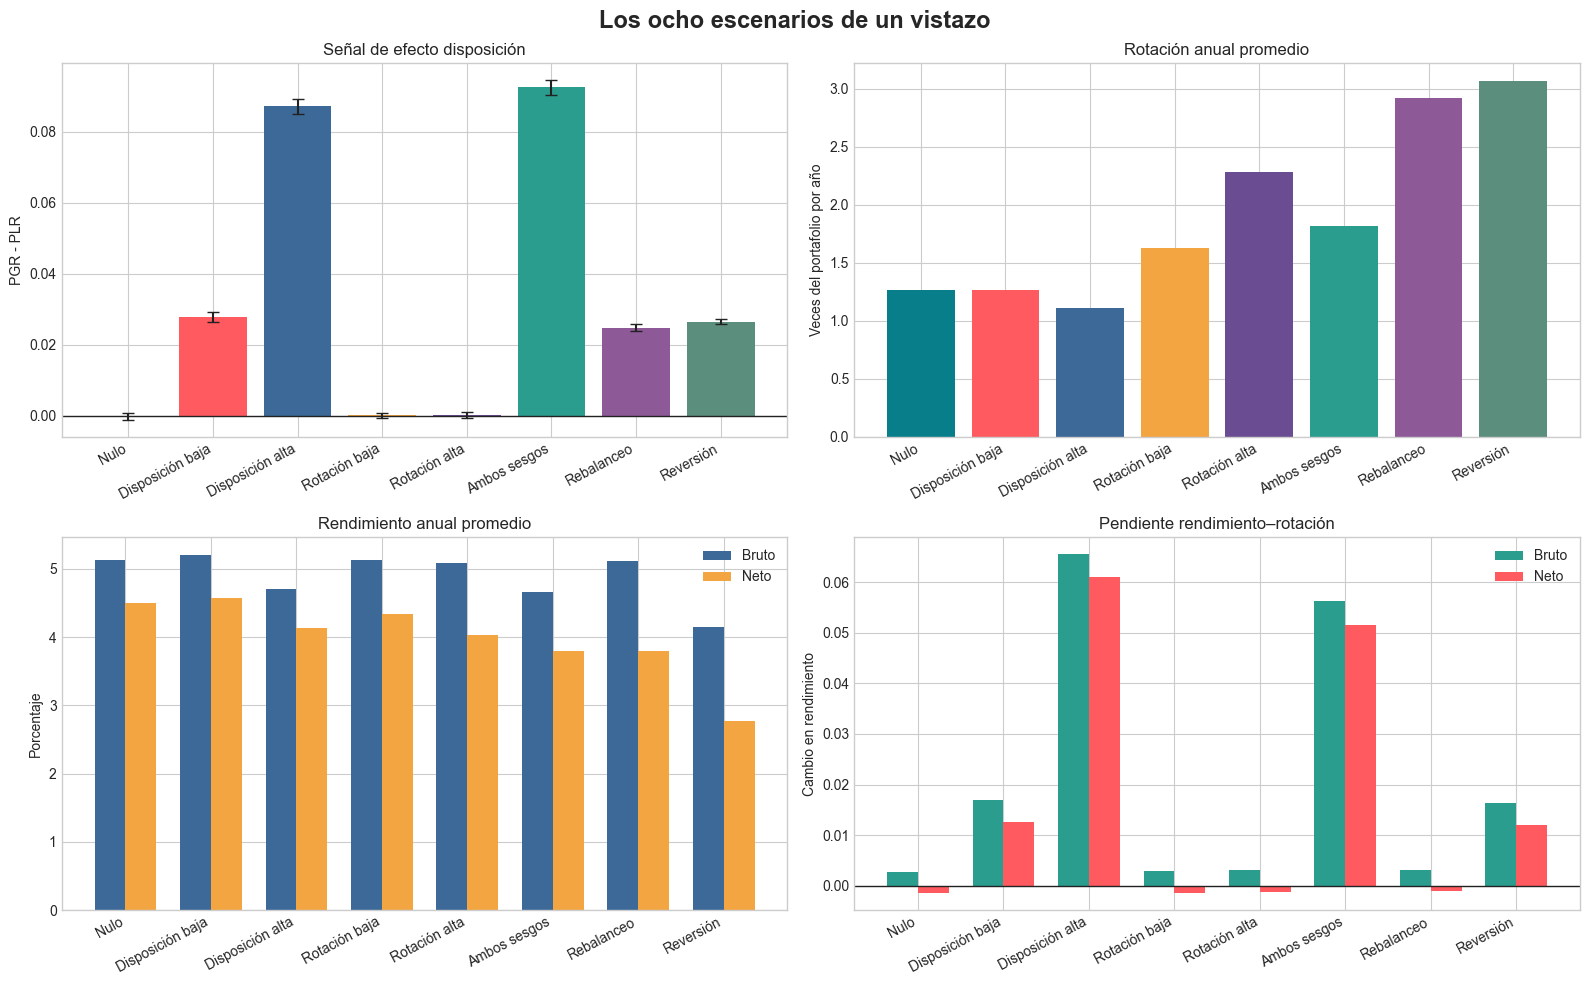

In [9]:
df = final_results_table.copy()
labels = [s.split(". ", 1)[1] for s in df["scenario"]]
x = np.arange(len(df))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

yerr = np.vstack([df["PGR_minus_PLR"] - df["CI_low"], df["CI_high"] - df["PGR_minus_PLR"]])
axes[0, 0].bar(x, df["PGR_minus_PLR"], color=COLORS)
axes[0, 0].errorbar(x, df["PGR_minus_PLR"], yerr=yerr, fmt="none", ecolor="#222222", capsize=4)
axes[0, 0].axhline(0, color="#222222", linewidth=1)
axes[0, 0].set_title("Señal de efecto disposición")
axes[0, 0].set_ylabel("PGR - PLR")

axes[0, 1].bar(x, df["turnover"], color=COLORS)
axes[0, 1].set_title("Rotación anual promedio")
axes[0, 1].set_ylabel("Veces del portafolio por año")

width = 0.36
axes[1, 0].bar(x - width/2, df["gross_return"] * 100, width, label="Bruto", color="#3C6997")
axes[1, 0].bar(x + width/2, df["net_return"] * 100, width, label="Neto", color="#F2A541")
axes[1, 0].set_title("Rendimiento anual promedio")
axes[1, 0].set_ylabel("Porcentaje")
axes[1, 0].legend(frameon=False)

axes[1, 1].bar(x - width/2, df["beta_gross"], width, label="Bruto", color="#2A9D8F")
axes[1, 1].bar(x + width/2, df["beta_net"], width, label="Neto", color="#FF5A5F")
axes[1, 1].axhline(0, color="#222222", linewidth=1)
axes[1, 1].set_title("Pendiente rendimiento–rotación")
axes[1, 1].set_ylabel("Cambio en rendimiento")
axes[1, 1].legend(frameon=False)

for ax in axes.flat:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=28, ha="right")

fig.suptitle("Los ocho escenarios de un vistazo", fontsize=17, fontweight="bold")
fig.tight_layout()
plt.show()


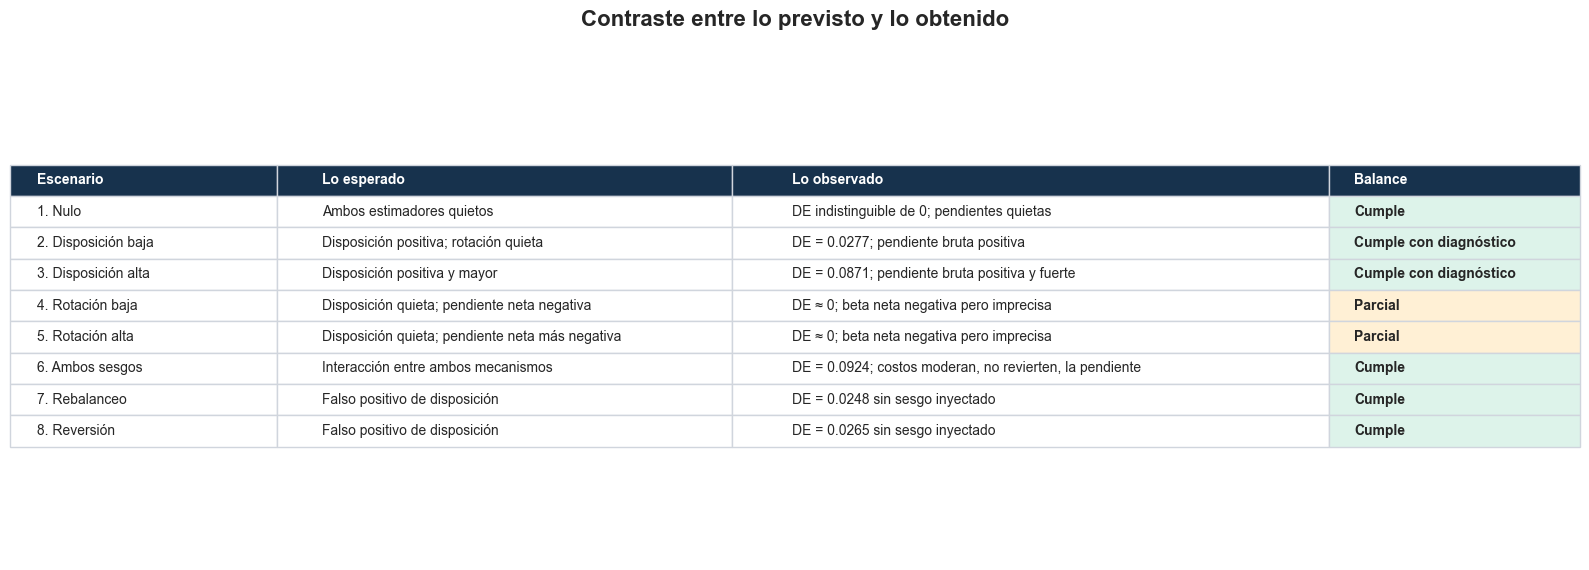

In [10]:
scorecard = pd.DataFrame({
    "Escenario": [scenario_specs[i]["name"] for i in range(1, 9)],
    "Lo esperado": [
        "Ambos estimadores quietos",
        "Disposición positiva; rotación quieta",
        "Disposición positiva y mayor",
        "Disposición quieta; pendiente neta negativa",
        "Disposición quieta; pendiente neta más negativa",
        "Interacción entre ambos mecanismos",
        "Falso positivo de disposición",
        "Falso positivo de disposición",
    ],
    "Lo observado": [
        "DE indistinguible de 0; pendientes quietas",
        "DE = 0.0277; pendiente bruta positiva",
        "DE = 0.0871; pendiente bruta positiva y fuerte",
        "DE ≈ 0; beta neta negativa pero imprecisa",
        "DE ≈ 0; beta neta negativa pero imprecisa",
        "DE = 0.0924; costos moderan, no revierten, la pendiente",
        "DE = 0.0248 sin sesgo inyectado",
        "DE = 0.0265 sin sesgo inyectado",
    ],
    "Balance": ["Cumple", "Cumple con diagnóstico", "Cumple con diagnóstico", "Parcial", "Parcial", "Cumple", "Cumple", "Cumple"],
})

fig, ax = plt.subplots(figsize=(16, 5.8))
ax.axis("off")
table = ax.table(cellText=scorecard.values, colLabels=scorecard.columns, loc="center", cellLoc="left", colLoc="left", colWidths=[0.17, 0.29, 0.38, 0.16])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.65)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D5DD")
    if row == 0:
        cell.set_facecolor("#17324D")
        cell.get_text().set_color("white")
        cell.get_text().set_weight("bold")
    elif col == 3:
        value = scorecard.iloc[row - 1, 3]
        cell.set_facecolor("#DDF3EA" if value != "Parcial" else "#FFF0D5")
        cell.get_text().set_weight("bold")
ax.set_title("Contraste entre lo previsto y lo obtenido", fontsize=16, fontweight="bold", pad=18)
plt.tight_layout()
plt.show()


In [11]:
def plot_scenario(sid):
    row = final_results_table.iloc[sid - 1]
    accounts = scenario_results[sid]["summary"]
    label = scenario_specs[sid]["name"]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    axes[0, 0].bar(["Ganancias\n(PGR)", "Pérdidas\n(PLR)"], [row["PGR"], row["PLR"]], color=["#2A9D8F", "#FF5A5F"])
    axes[0, 0].set_title("¿Qué se realiza con mayor frecuencia?")
    axes[0, 0].set_ylabel("Proporción")
    axes[0, 0].text(0.5, 0.93, f"Diferencia: {row['PGR_minus_PLR']:.4f}", transform=axes[0, 0].transAxes, ha="center", fontweight="bold")

    axes[0, 1].hist(accounts["turnover_annualized"], bins=30, color=COLORS[sid - 1], alpha=0.85)
    axes[0, 1].axvline(accounts["turnover_annualized"].mean(), color="#222222", linestyle="--", label=f"Media {row['turnover']:.2f}")
    axes[0, 1].set_title("Rotación entre cuentas")
    axes[0, 1].set_xlabel("Turnover anual")
    axes[0, 1].set_ylabel("Cuentas")
    axes[0, 1].legend(frameon=False)

    axes[1, 0].bar(["Bruto", "Neto"], [row["gross_return"] * 100, row["net_return"] * 100], color=["#3C6997", "#F2A541"])
    axes[1, 0].set_title("Rendimiento después de separar costos")
    axes[1, 0].set_ylabel("Rendimiento anual promedio (%)")
    axes[1, 0].text(0.5, 0.92, f"Brecha por costos: {row['cost_drag']*100:.2f} pp", transform=axes[1, 0].transAxes, ha="center", fontweight="bold")

    axes[1, 1].scatter(accounts["turnover_annualized"], accounts["gross_ann_return"] * 100, s=12, alpha=0.22, color="#2A9D8F", label="Bruto")
    axes[1, 1].scatter(accounts["turnover_annualized"], accounts["net_ann_return"] * 100, s=12, alpha=0.18, color="#FF5A5F", label="Neto")
    axes[1, 1].set_title("Cada cuenta: rotación y resultado")
    axes[1, 1].set_xlabel("Turnover anual")
    axes[1, 1].set_ylabel("Rendimiento anual (%)")
    axes[1, 1].legend(frameon=False)

    fig.suptitle(label, fontsize=17, fontweight="bold")
    fig.tight_layout()
    plt.show()


## Escenario 1. Punto de referencia: ningún sesgo

**Se esperaba:** que tanto el indicador de disposición como la relación entre rotación y rendimiento permanecieran quietos.

**Se obtuvo:** PGR fue 5.02% y PLR 5.05%; la diferencia fue -0.0002 y su intervalo de 95% incluyó cero. En términos cotidianos, el simulador realizó ganancias y pérdidas con prácticamente la misma frecuencia. Esto es una comprobación crucial: el estimador no fabrica un sesgo cuando no se inyecta ninguno.

La pendiente del rendimiento bruto fue 0.0027 y la del neto -0.0015; ambas son pequeñas e imprecisas. La separación entre bruto y neto sí aparece, porque incluso los traders sin sesgos pagan comisiones y spread al reemplazar posiciones. El escenario cumple la función de control.


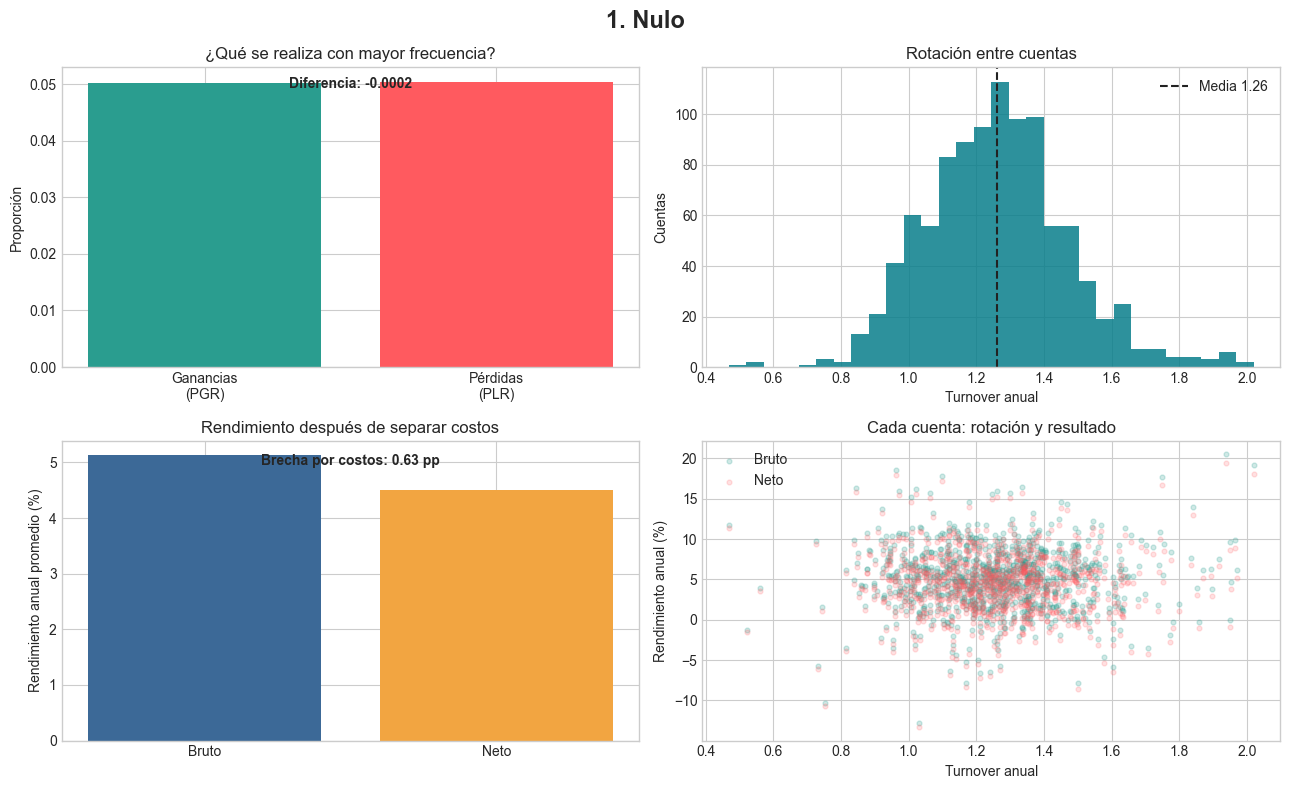

In [12]:
plot_scenario(1)


## Escenario 2. Efecto disposición bajo

**Se esperaba:** una señal positiva de disposición, sin activar sobreconfianza.

**Se obtuvo:** PGR subió a 6.58% y PLR bajó a 3.81%, produciendo una diferencia de 0.0277. El intervalo de confianza quedó completamente por encima de cero. El ratio PGR/PLR fue 1.73: por cada oportunidad comparable, una ganancia tuvo alrededor de 73% más probabilidad de realizarse que una pérdida.

La rotación promedio (1.27 veces al año) fue casi igual a la del escenario nulo, de modo que la señal no proviene de negociar más. La pendiente bruta positiva (0.0170) es un caso de causalidad inversa: las cuentas con más ganadores disponibles tienden a vender más y también a mostrar mejor desempeño. No hay información futura en la decisión.


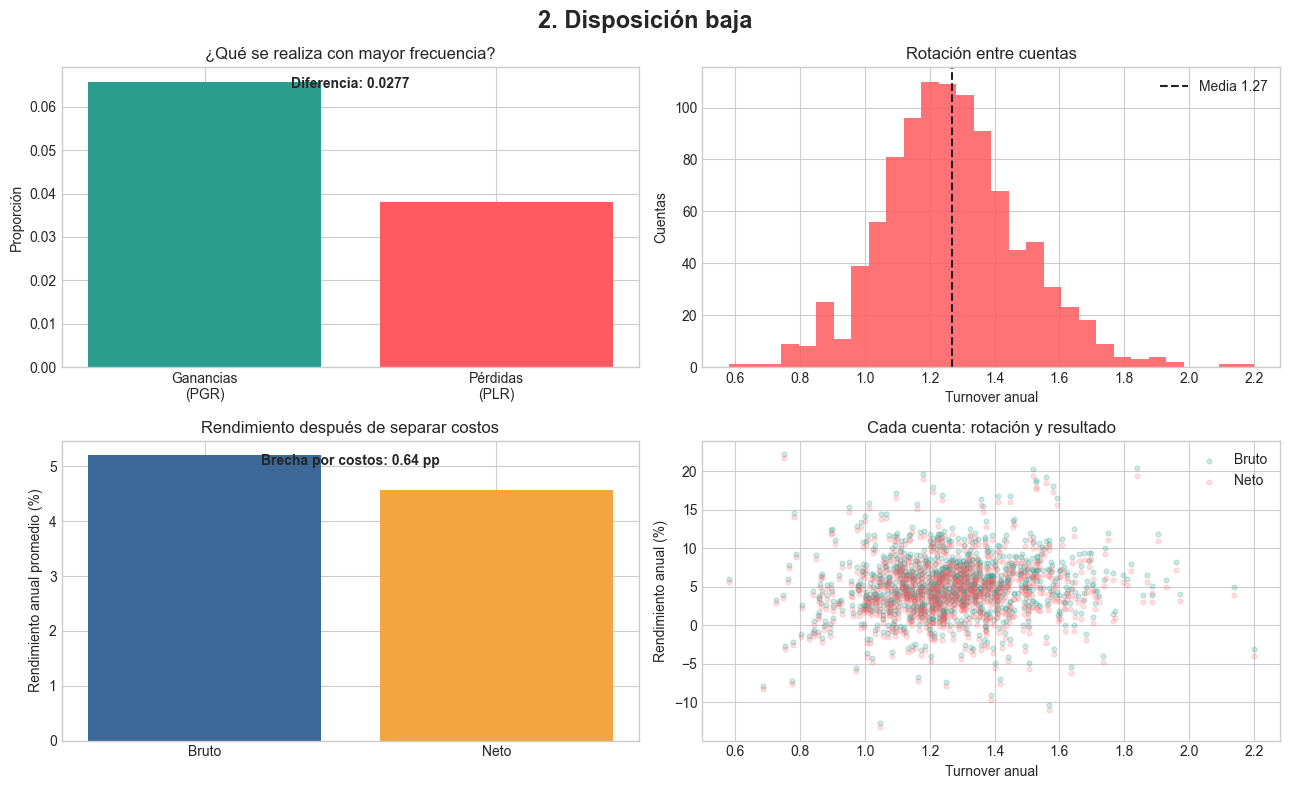

In [13]:
plot_scenario(2)


## Escenario 3. Efecto disposición alto

**Se esperaba:** la misma señal del escenario 2, pero claramente más grande.

**Se obtuvo:** la diferencia PGR-PLR alcanzó 0.0871, más de tres veces la del escenario de disposición baja. PGR fue 10.10% y PLR apenas 1.39%; el ratio llegó a 7.25. El estimador responde de forma monotónica a la intensidad inyectada, que era la prueba central del proyecto.

La rotación total cayó a 1.11. No es una contradicción: con un sesgo fuerte, los perdedores permanecen en cartera mucho tiempo y dejan menos oportunidades para reemplazar posiciones. La pendiente bruta positiva y significativa (0.0656) vuelve a reflejar causalidad inversa y efectos de trayectoria, no capacidad predictiva.


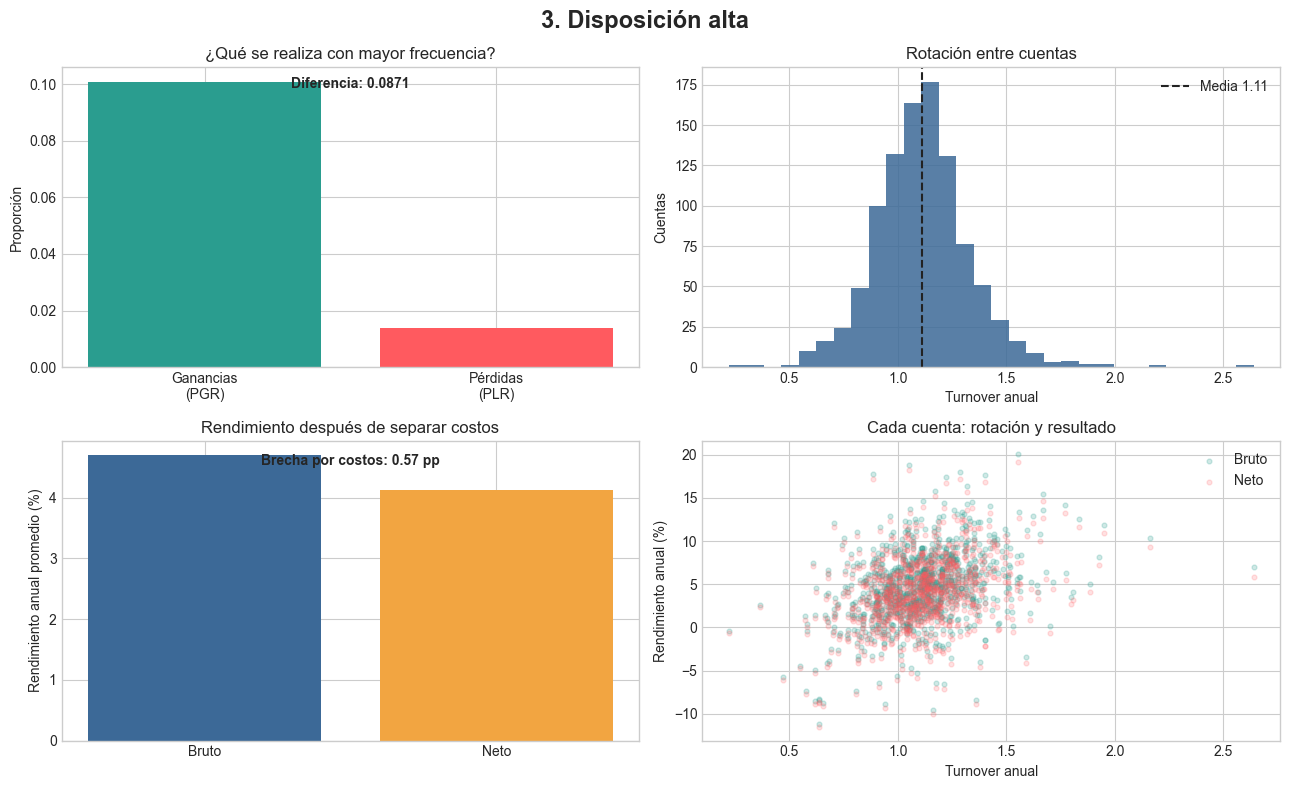

In [14]:
plot_scenario(3)


## Escenario 4. Sobreconfianza o rotación baja

**Se esperaba:** disposición quieta, rendimiento bruto sin relación sistemática con turnover y rendimiento neto decreciente por costos.

**Se obtuvo:** PGR-PLR fue 0.0002, con intervalo que incluye cero. El aumento de actividad por sí solo no se confundió con efecto disposición. El turnover subió a 1.62 frente a 1.26 en el escenario nulo.

La pendiente bruta fue 0.0028 y la neta -0.0014. La dirección bruto–neto coincide con la predicción, pero ninguna pendiente individual es estadísticamente precisa. Por eso el cumplimiento es parcial: los costos existen y se ven con claridad en la brecha bruto–neto, pero esta regresión transversal no logra aislar una pendiente neta significativa.


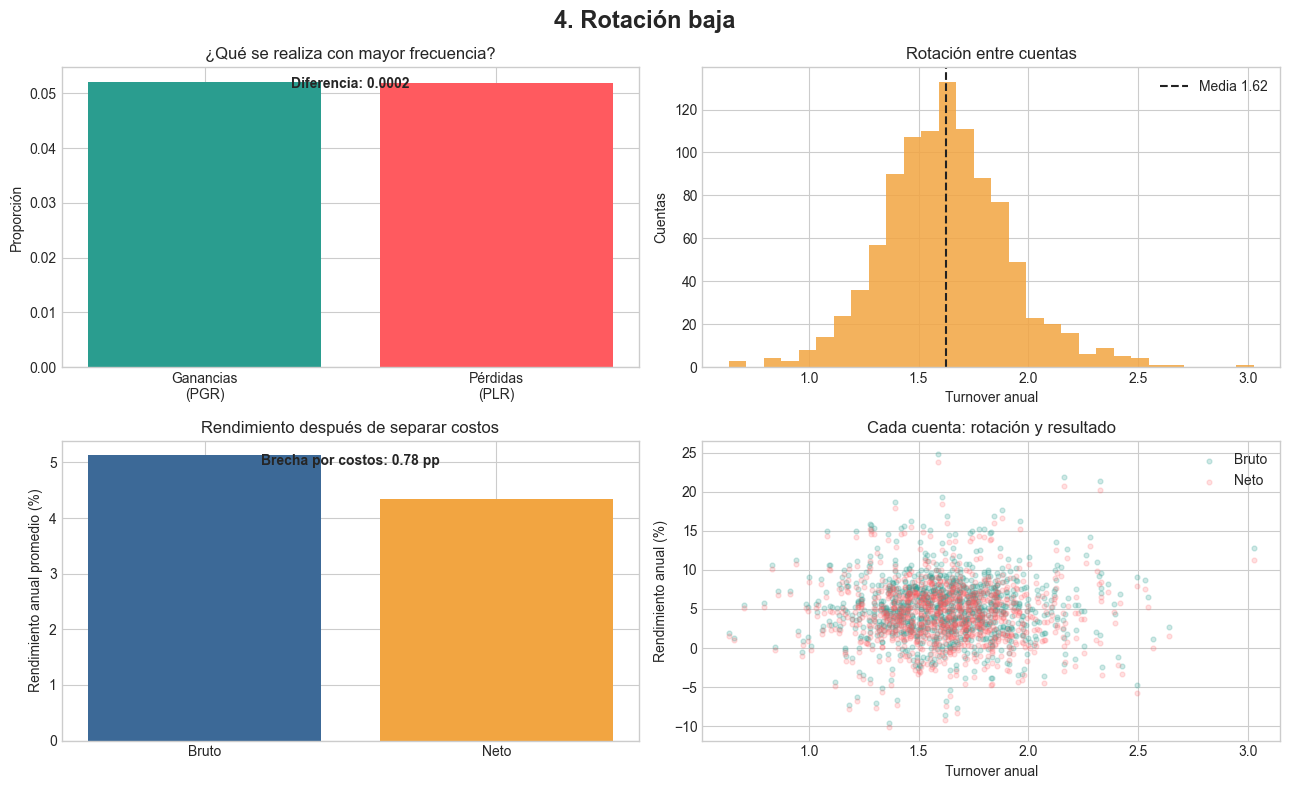

In [15]:
plot_scenario(4)


## Escenario 5. Sobreconfianza o rotación alta

**Se esperaba:** aún más turnover, disposición quieta y una relación neta más negativa.

**Se obtuvo:** el turnover llegó a 2.28 veces al año, el mayor entre los escenarios conductuales sin confusores. PGR-PLR siguió prácticamente en cero (0.0002), lo que confirma que kappa eleva frecuencia sin alterar la asimetría entre ganancias y pérdidas.

El rendimiento bruto promedio fue 5.08% y el neto 4.02%; la mayor actividad amplió la pérdida por costos. La pendiente neta (-0.0011) no fue más negativa ni significativa que en el escenario 4. El resultado agregado de costos sí es más fuerte, pero la predicción sobre la pendiente individual sólo se cumple en dirección, no en precisión ni magnitud.


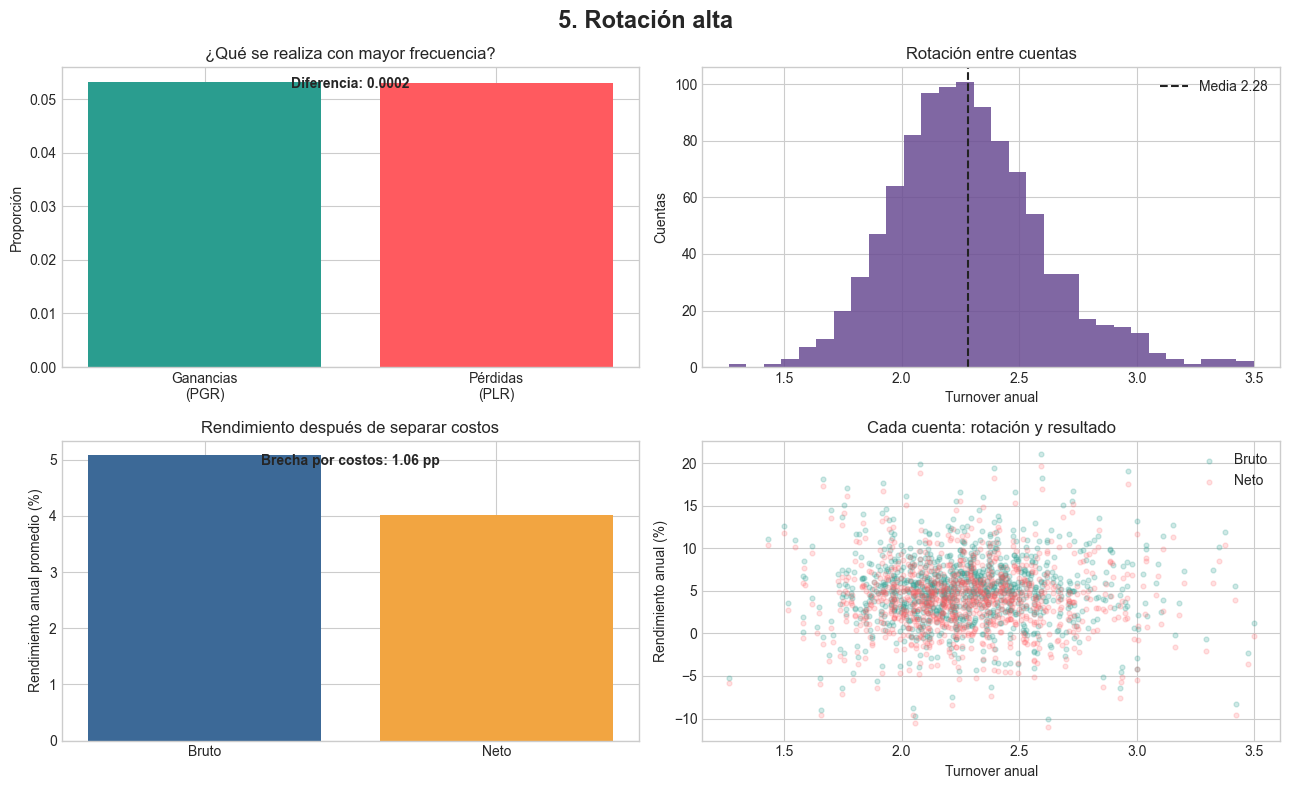

In [16]:
plot_scenario(5)


## Escenario 6. Ambos mecanismos activos

**Se esperaba:** que los dos estimadores interactuaran, porque retener perdedores reduce la rotación que kappa intenta aumentar.

**Se obtuvo:** PGR-PLR fue 0.0924, incluso algo mayor que con disposición alta sola. El turnover fue 1.82: kappa lo elevó frente al escenario 3, pero no hasta el 2.28 del escenario 5 porque delta mantiene pérdidas inmovilizadas.

Las pendientes bruta y neta fueron positivas (0.0562 y 0.0516). La diferencia entre ambas sigue siendo el costo de operar, pero el canal de causalidad inversa generado por vender ganadores es mayor que ese costo. Este escenario muestra por qué el coeficiente de turnover no debe interpretarse sin conocer la regla de venta.


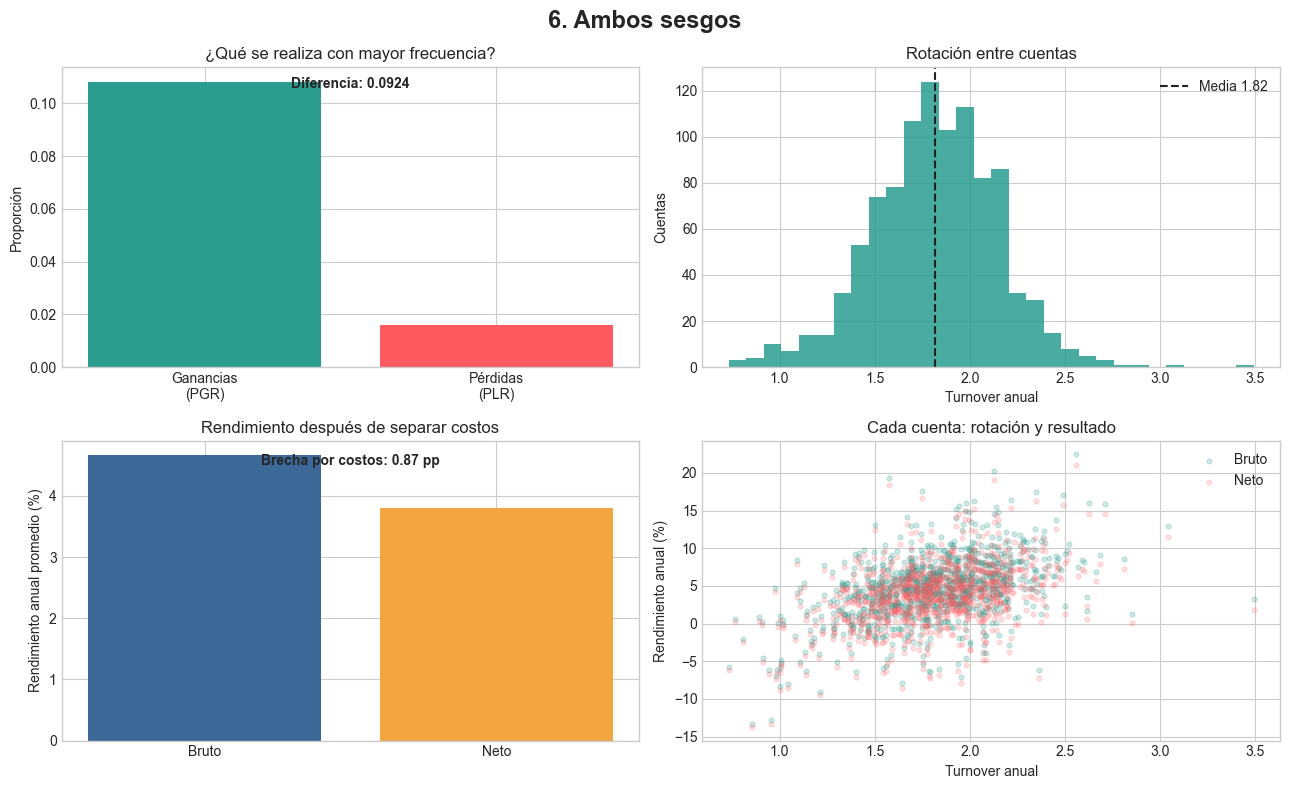

In [17]:
plot_scenario(6)


## Escenario 7. Rebalanceo como falso positivo

**Se esperaba:** que el estimador de disposición se activara aun con delta igual a cero.

**Se obtuvo:** PGR-PLR fue 0.0248 y el ratio 1.57, casi del mismo tamaño que el escenario de disposición baja. Las posiciones que suben de precio aumentan su peso; al recortarlas para volver al objetivo, el rebalanceo vende ganadores con mayor frecuencia.

El turnover llegó a 2.92 y la brecha entre rendimiento bruto y neto fue amplia. Nada de esto requiere aversión a realizar pérdidas: una regla prudente de control de pesos produce el mismo patrón observable. PGR-PLR detecta una asimetría real, pero no identifica por sí solo su causa psicológica.


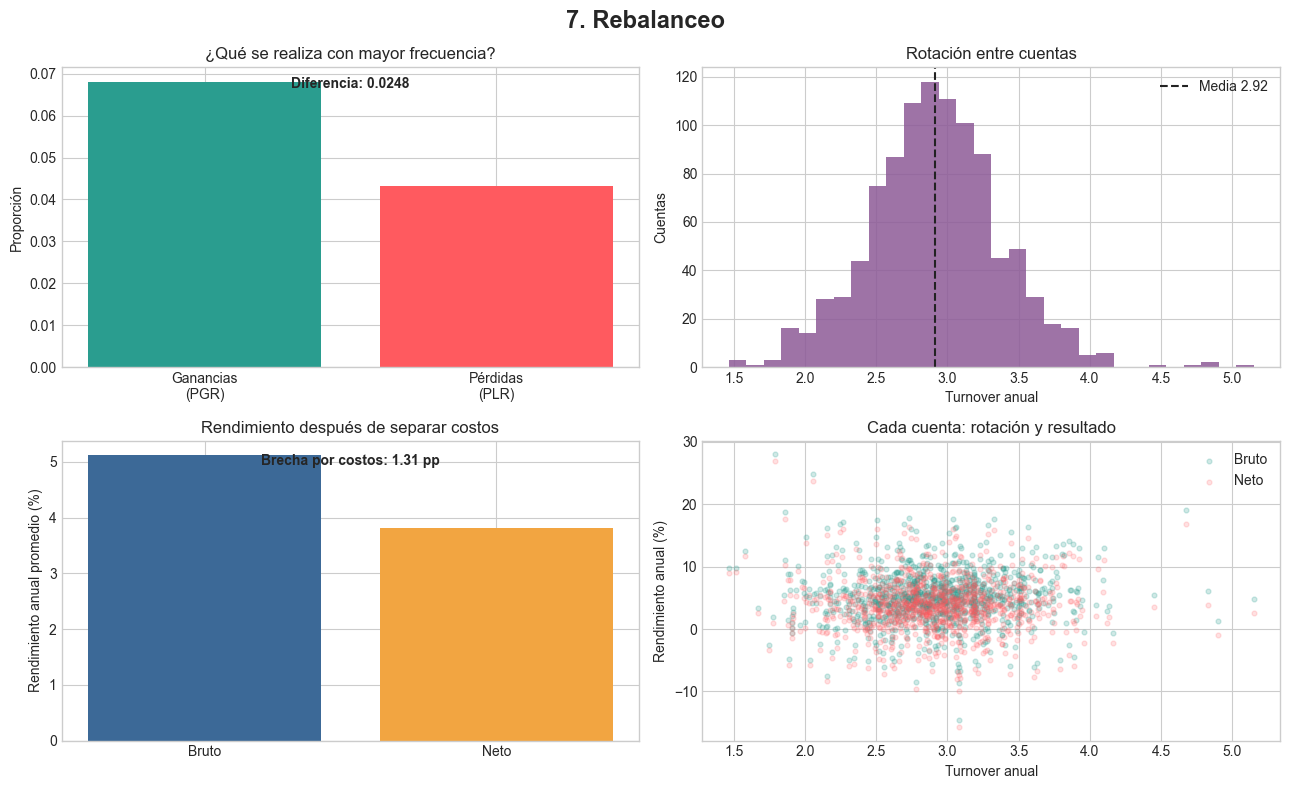

In [18]:
plot_scenario(7)


## Escenario 8. Creencia en reversión a la media

**Se esperaba:** otro falso positivo de disposición, esta vez por vender ganadores recientes y comprar rezagados.

**Se obtuvo:** PGR-PLR fue 0.0265 y el ratio 1.61, nuevamente casi idénticos al escenario de disposición baja. La regla usa sólo información pasada; por tanto, el resultado no se debe a filtración de rendimientos futuros.

Este escenario tuvo el turnover más alto (3.06), un rendimiento bruto de 4.14% y neto de 2.77%. La pendiente bruta positiva (0.0164) aparece porque la actividad depende de éxitos recientes y porque la selección repetida cambia las trayectorias compuestas. El diagnóstico es un confusor económico legítimo, no un error de precios.


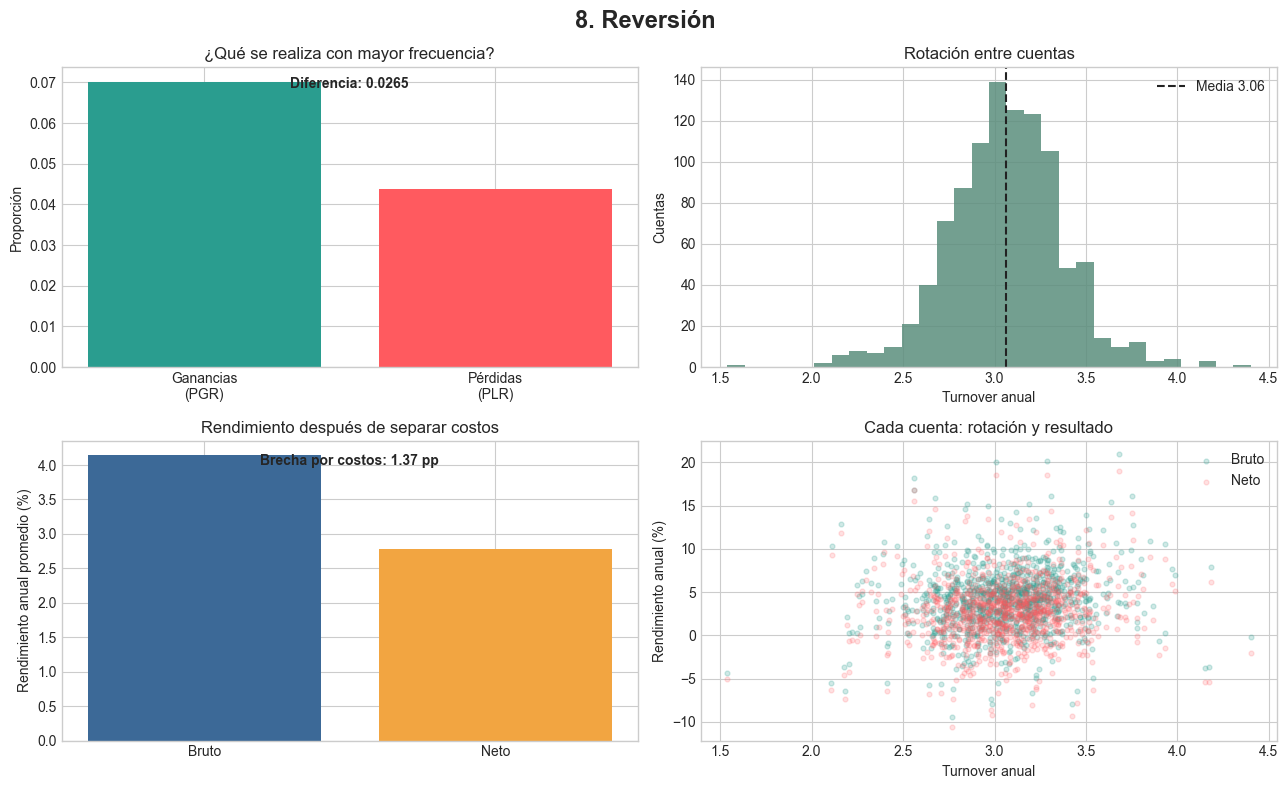

In [19]:
plot_scenario(8)


## Incertidumbre: señales firmes y señales débiles

Los intervalos del efecto disposición separan con nitidez los escenarios nulo y de rotación de aquellos con disposición o confusores. En cambio, las pendientes de rendimiento son mucho menos precisas porque el ruido de mercado entre cuentas es grande respecto al costo marginal de operar.


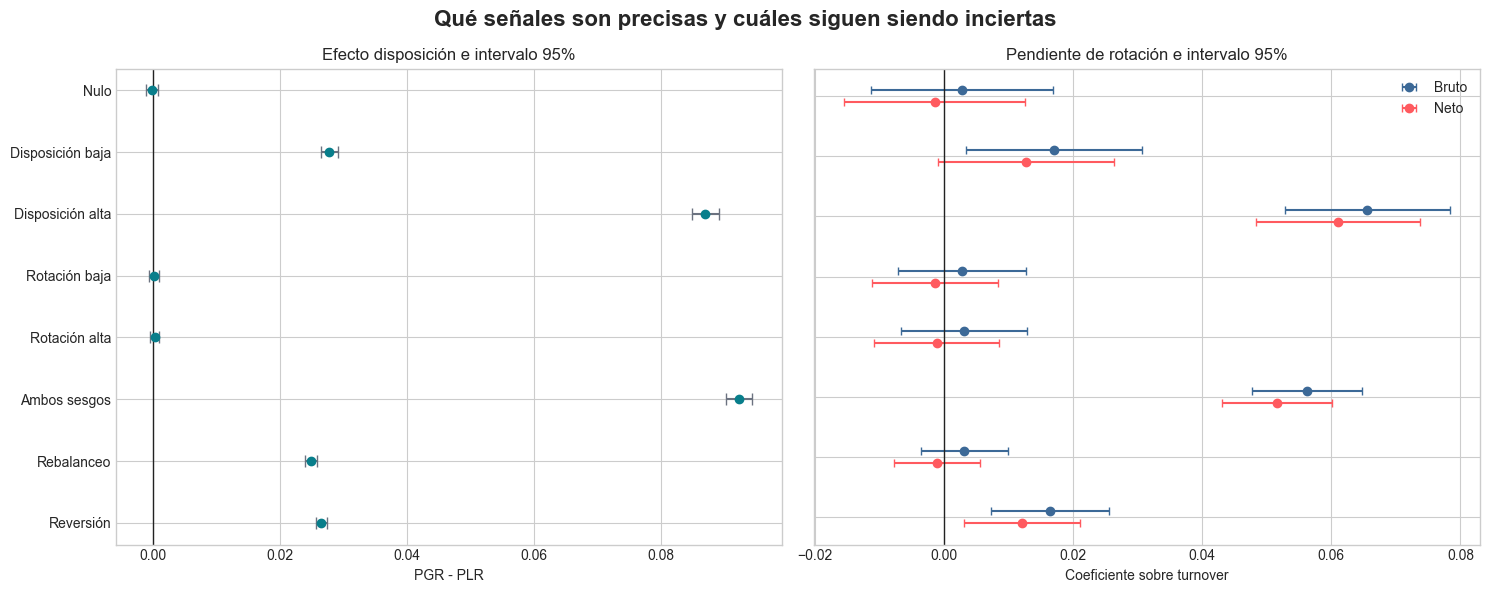

In [20]:
df = final_results_table.copy()
y = np.arange(len(df))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

xerr_de = np.vstack([df["PGR_minus_PLR"] - df["CI_low"], df["CI_high"] - df["PGR_minus_PLR"]])
axes[0].errorbar(df["PGR_minus_PLR"], y, xerr=xerr_de, fmt="o", color="#087E8B", ecolor="#6B7280", capsize=4)
axes[0].axvline(0, color="#222222", linewidth=1)
axes[0].set_yticks(y)
axes[0].set_yticklabels([s.split(". ", 1)[1] for s in df["scenario"]])
axes[0].invert_yaxis()
axes[0].set_title("Efecto disposición e intervalo 95%")
axes[0].set_xlabel("PGR - PLR")

axes[1].errorbar(df["beta_gross"], y - 0.1, xerr=1.96 * df["SE_gross"], fmt="o", label="Bruto", color="#3C6997", capsize=3)
axes[1].errorbar(df["beta_net"], y + 0.1, xerr=1.96 * df["SE_net"], fmt="o", label="Neto", color="#FF5A5F", capsize=3)
axes[1].axvline(0, color="#222222", linewidth=1)
axes[1].set_yticks(y)
axes[1].set_yticklabels([])
axes[1].invert_yaxis()
axes[1].set_title("Pendiente de rotación e intervalo 95%")
axes[1].set_xlabel("Coeficiente sobre turnover")
axes[1].legend(frameon=False)

fig.suptitle("Qué señales son precisas y cuáles siguen siendo inciertas", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()


## Independencia e interacción

En el escenario 6, la correlación entre delta y kappa inyectados es -0.0169, esencialmente cero. Sin embargo, delta se correlaciona negativamente con el turnover realizado (-0.3912): retener perdedores reduce las oportunidades de venta. Kappa conserva una relación positiva con turnover (0.1981).

Esto distingue **parámetro** de **conducta observada**. Si delta y kappa hubieran sido correlacionados desde el diseño, turnover mezclaría deliberadamente ambos sesgos y el coeficiente de sobreconfianza perdería una interpretación clara.


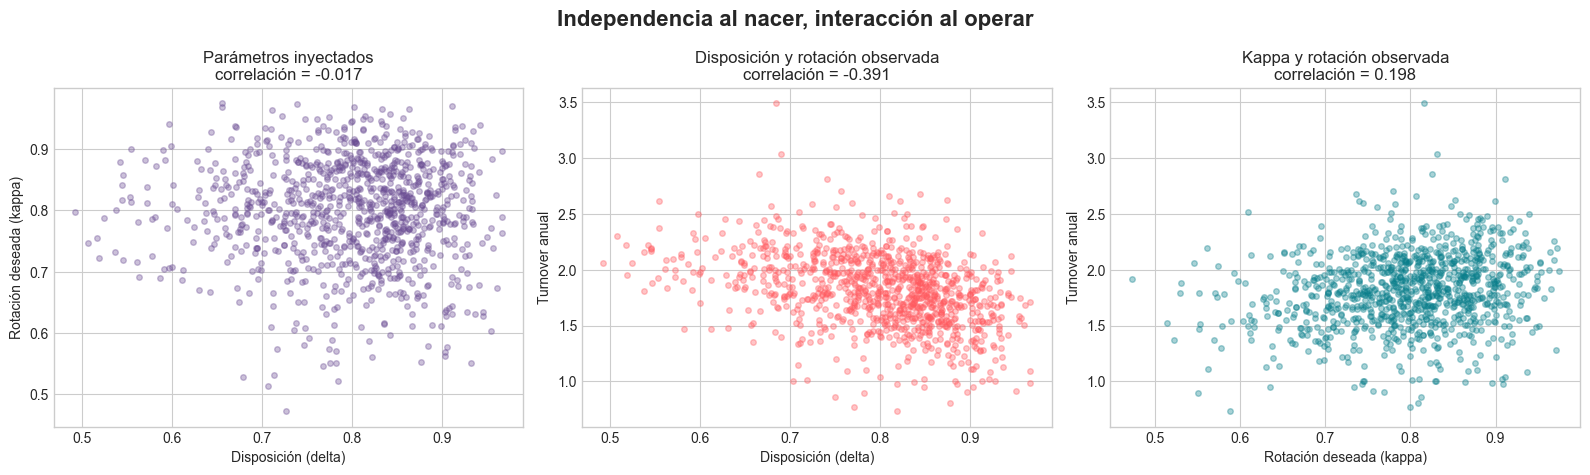

In [21]:
df6 = scenario_results[6]["summary"]
c_dk = df6["delta"].corr(df6["kappa"])
c_dt = df6["delta"].corr(df6["turnover_annualized"])
c_kt = df6["kappa"].corr(df6["turnover_annualized"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].scatter(df6["delta"], df6["kappa"], s=16, alpha=0.35, color="#6A4C93")
axes[0].set_title(f"Parámetros inyectados\ncorrelación = {c_dk:.3f}")
axes[0].set_xlabel("Disposición (delta)")
axes[0].set_ylabel("Rotación deseada (kappa)")

axes[1].scatter(df6["delta"], df6["turnover_annualized"], s=16, alpha=0.35, color="#FF5A5F")
axes[1].set_title(f"Disposición y rotación observada\ncorrelación = {c_dt:.3f}")
axes[1].set_xlabel("Disposición (delta)")
axes[1].set_ylabel("Turnover anual")

axes[2].scatter(df6["kappa"], df6["turnover_annualized"], s=16, alpha=0.35, color="#087E8B")
axes[2].set_title(f"Kappa y rotación observada\ncorrelación = {c_kt:.3f}")
axes[2].set_xlabel("Rotación deseada (kappa)")
axes[2].set_ylabel("Turnover anual")

fig.suptitle("Independencia al nacer, interacción al operar", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()


## El canal de costos sí está presente

Aunque las pendientes netas individuales de los escenarios 4 y 5 no son significativas, la pérdida **bruto menos neto** crece de forma muy estable con turnover. Su pendiente es aproximadamente 0.0042: una vuelta adicional del portafolio al año agrega cerca de **0.42 puntos porcentuales** de pérdida anual.

Esta es la prueba más limpia de que la negociación frecuente cuesta dinero en el simulador. La falta de significancia de beta neta no niega los costos; indica que el retorno bruto aleatorio introduce suficiente dispersión como para ocultar el pequeño efecto en una regresión transversal separada.


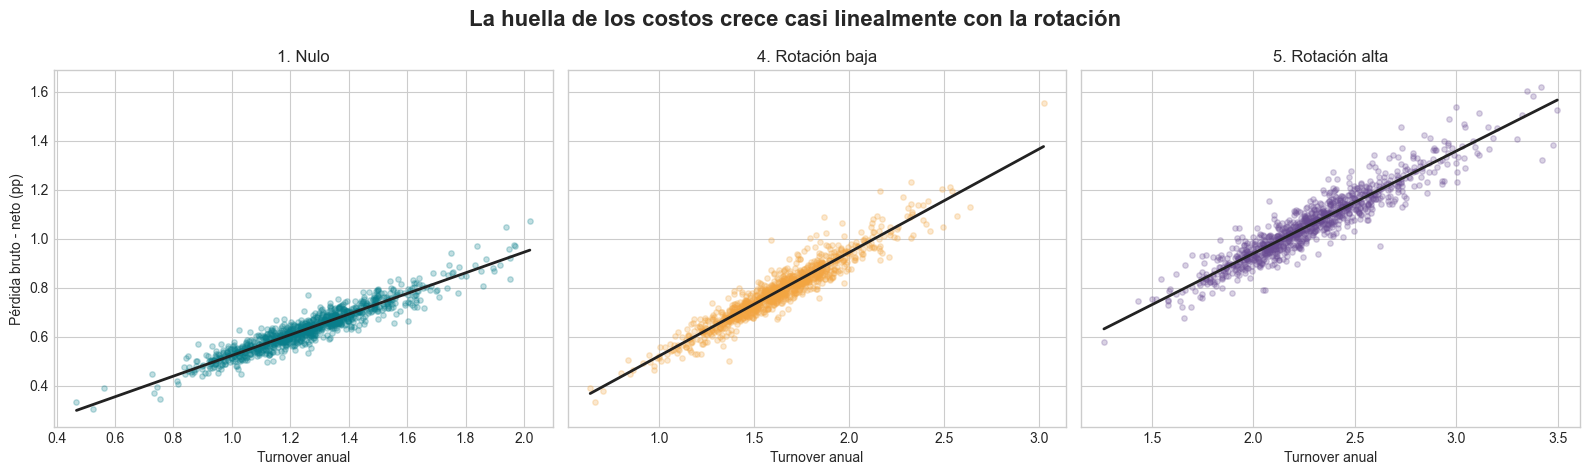

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, sid in zip(axes, [1, 4, 5]):
    accounts = scenario_results[sid]["summary"].copy()
    x = accounts["turnover_annualized"].to_numpy()
    y = (accounts["gross_ann_return"] - accounts["net_ann_return"]).to_numpy() * 100
    ax.scatter(x, y, s=15, alpha=0.25, color=COLORS[sid - 1])
    coef = np.polyfit(x, y, 1)
    grid = np.linspace(x.min(), x.max(), 100)
    ax.plot(grid, np.polyval(coef, grid), color="#222222", linewidth=2)
    ax.set_title(scenario_specs[sid]["name"])
    ax.set_xlabel("Turnover anual")
axes[0].set_ylabel("Pérdida bruto - neto (pp)")
fig.suptitle("La huella de los costos crece casi linealmente con la rotación", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()


## Diagnóstico de pendientes brutas

No se encontró filtración de información futura: los precios se fijan antes de operar y ninguna regla consulta días posteriores. Tampoco hay arrastre de efectivo, porque el dinero se reinvierte el mismo día, ni spread dentro del precio bruto, porque el libro gross siempre usa el precio medio.

Las pendientes brutas positivas de los escenarios 2, 3 y 6 se explican principalmente por **causalidad inversa**: una cuenta que ha acumulado ganadores tiene más posiciones con alta probabilidad de venta, así que un buen resultado previo produce turnover. En el escenario 8 se suma la selección explícita de ganadores recientes para vender y de rezagados para comprar. Los efectos de trayectoria y composición son legítimos dentro del experimento, pero no deben presentarse como habilidad de inversión.


## Conclusiones

1. **El efecto disposición se recupera correctamente.** PGR-PLR pasa de prácticamente cero a 0.0277 y 0.0871 cuando delta aumenta de 0 a 0.3 y 0.8.
2. **Kappa aumenta la actividad sin crear disposición.** El turnover crece de 1.26 a 1.62 y 2.28, mientras PGR-PLR permanece cerca de cero.
3. **Los costos importan.** Más turnover amplía de manera casi lineal la distancia entre rendimiento bruto y neto.
4. **La regresión de sobreconfianza tiene potencia limitada en esta realización.** Las pendientes netas de los escenarios 4 y 5 son negativas, pero no significativas y no se vuelven más negativas al subir kappa.
5. **PGR-PLR no identifica una causa única.** Rebalanceo y reversión generan señales de 0.0248 y 0.0265, casi iguales al 0.0277 de una disposición verdadera baja.
6. **La independencia estructural no evita interacción conductual.** Delta y kappa nacen independientes, pero delta reduce el turnover que finalmente observamos.

El simulador supera las validaciones de definición y contabilidad. Su mensaje más valioso no es sólo que los estimadores “funcionan”, sino que un patrón estadístico puede recuperarse perfectamente y aun así admitir explicaciones económicas distintas.


In [23]:
final_results_table.to_csv("resultados_completos_8_escenarios.csv", index=False)
report_table.to_csv("tabla_final_reporte.csv", index=False)
print("Tablas exportadas: resultados_completos_8_escenarios.csv y tabla_final_reporte.csv")


Tablas exportadas: resultados_completos_8_escenarios.csv y tabla_final_reporte.csv
